# 杰瑞股份 (002353.SZ) 量化分析报告 (完整版)

**分析周期**: 2025-07-02 至 2026-07-01 (242个交易日)

**数据来源**: Tushare Pro (通过 MCP 接口)

**包含内容**:
- 📊 数据基础诊断 & 描述性统计
- 📈 价格走势、K线图、量价关系
- 📉 收益率分布、累计净值
- 🎯 风险指标：夏普比率、最大回撤、盈亏比
- 🔧 技术指标：RSI、MACD、布林带、KDJ
- 📋 综合信号汇总

---

## 1. 环境准备与数据加载

导入所需的 Python 库，加载已存储的日线数据（注：数据已做**前复权**处理，基于 Tushare 复权因子 adj_factor 计算）。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC', 'Heiti SC']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (16, 9)

print('✅ 环境准备完毕')

/Users/mac/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/z8/l5gtpn214dlf6ltttjvh5lhh0000gn/T/matplotlib-2kk2mtgp because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


✅ 环境准备完毕


In [2]:
# 加载数据
df = pd.read_csv('杰瑞股份_日线_前复权.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

print(f'📊 数据概览')
print(f'   股票代码: 002353.SZ')
print(f'   时间范围: {df.index[0].strftime("%Y-%m-%d")} ~ {df.index[-1].strftime("%Y-%m-%d")}')
print(f'   交易日数: {len(df)}')
print(f'   起始价: ¥{df["close"].iloc[0]:.2f}')
print(f'   最新价: ¥{df["close"].iloc[-1]:.2f}')
print(f'   最高价: ¥{df["high"].max():.2f}')
print(f'   最低价: ¥{df["low"].min():.2f}')
total_pct = (df["close"].iloc[-1]/df["close"].iloc[0] - 1) * 100
print(f'   总涨幅: {total_pct:+.2f}%')
print(f'   总成交额: ¥{df["amount"].sum()/1e8:.1f}亿')
print(f'   数据复权状态: 前复权（基于 Tushare adj_factor，最新因子 8.7659）')

📊 数据概览
   股票代码: 002353.SZ
   时间范围: 2025-07-02 ~ 2026-07-01
   交易日数: 242
   起始价: ¥34.80
   最新价: ¥154.64
   最高价: ¥175.50
   最低价: ¥33.42
   总涨幅: +344.43%
   总成交额: ¥3.8亿
   数据复权状态: 前复权（基于 Tushare adj_factor，最新因子 8.7659）


In [3]:
# 前5行和后5行预览
print('=== 前5个交易日 ===')
display(df.head())
print()
print('=== 后5个交易日 ===')
display(df.tail())

=== 前5个交易日 ===


,open,high,low,close,pre_close,change,pct_chg,vol,amount
date,,,,,,,,,
2025-07-02,34.735680,35.192206,34.616587,34.795227,34.566964,0.228263,0.660350,66536.54,233817.658
2025-07-03,34.745605,34.914321,33.822628,33.991344,34.795227,-0.803883,-2.310325,74906.21,257934.702
2025-07-04,33.842477,34.328777,33.753157,34.259305,33.991344,0.267961,0.788321,86662.49,297464.852
2025-07-07,34.179909,34.358550,33.673761,33.743232,34.259305,-0.516073,-1.506373,86586.54,295642.718
2025-07-08,33.743232,34.289079,33.415724,33.852402,33.743232,0.109169,0.323529,90912.21,310249.394



=== 后5个交易日 ===


,open,high,low,close,pre_close,change,pct_chg,vol,amount
date,,,,,,,,,
2026-06-25,159.19,167.99,159.19,163.51,159.14,4.37,2.746010,147621.59,2.421744e+06
2026-06-26,163.00,166.70,160.03,161.53,163.51,-1.98,-1.210935,115971.89,1.892203e+06
2026-06-29,163.17,165.63,145.40,150.69,161.53,-10.84,-6.710828,268314.13,4.055332e+06
2026-06-30,151.49,156.98,150.92,152.50,150.69,1.81,1.201141,147242.22,2.259134e+06
2026-07-01,154.09,162.48,153.44,154.64,152.50,2.14,1.403279,138525.63,2.192943e+06


## 2. 数据基础诊断分析

在进行量化分析之前，必须对数据进行全面的质量检查。

### 2.1 缺失值与数据完整性检查

In [4]:
print('=' * 60)
print('  2.1 缺失值检查')
print('=' * 60)

# 缺失值统计
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'缺失数量': missing, '缺失比例(%)': missing_pct})
print(missing_df.to_string())

# 重复日期检查
dup_dates = df.index.duplicated().sum()
print(f'\n重复日期数: {dup_dates}')

# 交易日对比
full_range = pd.date_range(df.index.min(), df.index.max(), freq='B')
print(f'理论工作日: {len(full_range)}')
print(f'实际交易日: {len(df)}')
print(f'差异: {len(full_range) - len(df)} 天')
missing_dates = full_range.difference(df.index)
print(f'缺失日期(主要为节假日): {missing_dates[:10].strftime("%Y-%m-%d").tolist()}')

# OHLC 一致性检查
bad_high = (df['high'] < df[['open','close']].max(axis=1)).sum()
bad_low = (df['low'] > df[['open','close']].min(axis=1)).sum()
print(f'\nHigh < max(Open,Close) 异常: {bad_high}')
print(f'Low > min(Open,Close) 异常: {bad_low}')

if missing.sum() == 0 and dup_dates == 0 and bad_high == 0 and bad_low == 0:
    print('\n✅ 数据质量优秀：无缺失、无重复、OHLC逻辑一致！')

  2.1 缺失值检查
           缺失数量  缺失比例(%)
open          0      0.0
high          0      0.0
low           0      0.0
close         0      0.0
pre_close     0      0.0
change        0      0.0
pct_chg       0      0.0
vol           0      0.0
amount        0      0.0

重复日期数: 0
理论工作日: 261
实际交易日: 242
差异: 19 天
缺失日期(主要为节假日): ['2025-10-01', '2025-10-02', '2025-10-03', '2025-10-06', '2025-10-07', '2025-10-08', '2026-01-01', '2026-01-02', '2026-02-16', '2026-02-17']

High < max(Open,Close) 异常: 0
Low > min(Open,Close) 异常: 0

✅ 数据质量优秀：无缺失、无重复、OHLC逻辑一致！


### 2.2 描述性统计分析

In [5]:
print('=' * 60)
print('  2.2 描述性统计')
print('=' * 60)

desc_cols = ['open', 'high', 'low', 'close', 'vol', 'amount', 'pct_chg']
desc = df[desc_cols].describe()
display(desc.round(2))

# 偏度和峰度
print('\n📐 偏度(Skewness) & 峰度(Kurtosis):')
for col in ['close', 'vol', 'pct_chg']:
    s = df[col].skew()
    k = df[col].kurtosis()
    skew_desc = '右偏' if s > 0.5 else ('左偏' if s < -0.5 else '近似对称')
    kurt_desc = '尖峰厚尾' if k > 1 else ('扁平' if k < -1 else '接近正态')
    print(f'  {col:>10s}: 偏度={s:+.4f}({skew_desc}), 峰度={k:+.4f}({kurt_desc})')

# 极端波动
ext_up = df[df['pct_chg'] >= 9.5]
ext_down = df[df['pct_chg'] <= -9.5]
print(f'\n📊 极端波动:')
print(f'  涨幅≥9.5%: {len(ext_up)} 天')
print(f'  跌幅≤-9.5%: {len(ext_down)} 天')
if len(ext_up) > 0:
    print(f'  涨停日: {ext_up.index.strftime("%Y-%m-%d").tolist()}')

  2.2 描述性统计


,open,high,low,close,vol,amount,pct_chg
count,242.00,242.00,242.00,242.00,242.00,242.00,242.00
mean,82.80,85.30,80.73,83.08,166591.68,1562148.97,0.69
std,38.56,40.17,37.21,38.65,90795.65,1197311.10,3.66
min,33.74,34.11,33.42,33.69,24456.79,138009.67,-7.46
25%,49.87,50.79,48.94,49.67,89346.32,424494.20,-1.77
50%,72.72,73.91,70.30,72.50,155044.22,1419616.32,0.34
75%,112.23,116.50,109.23,111.85,218248.15,2430245.63,2.71
max,173.66,175.50,164.22,173.66,572378.86,6652425.28,10.01



📐 偏度(Skewness) & 峰度(Kurtosis):
       close: 偏度=+0.5665(右偏), 峰度=-0.9790(接近正态)
         vol: 偏度=+0.9747(右偏), 峰度=+1.2968(尖峰厚尾)
     pct_chg: 偏度=+0.4916(近似对称), 峰度=+0.1499(接近正态)

📊 极端波动:
  涨幅≥9.5%: 8 天
  跌幅≤-9.5%: 0 天
  涨停日: ['2025-08-07', '2025-11-28', '2025-12-01', '2025-12-03', '2026-01-14', '2026-04-08', '2026-05-06', '2026-06-04']


## 3. 收盘价走势与均线

绘制过去一年的每日收盘价曲线，叠加20日和60日均线。

findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


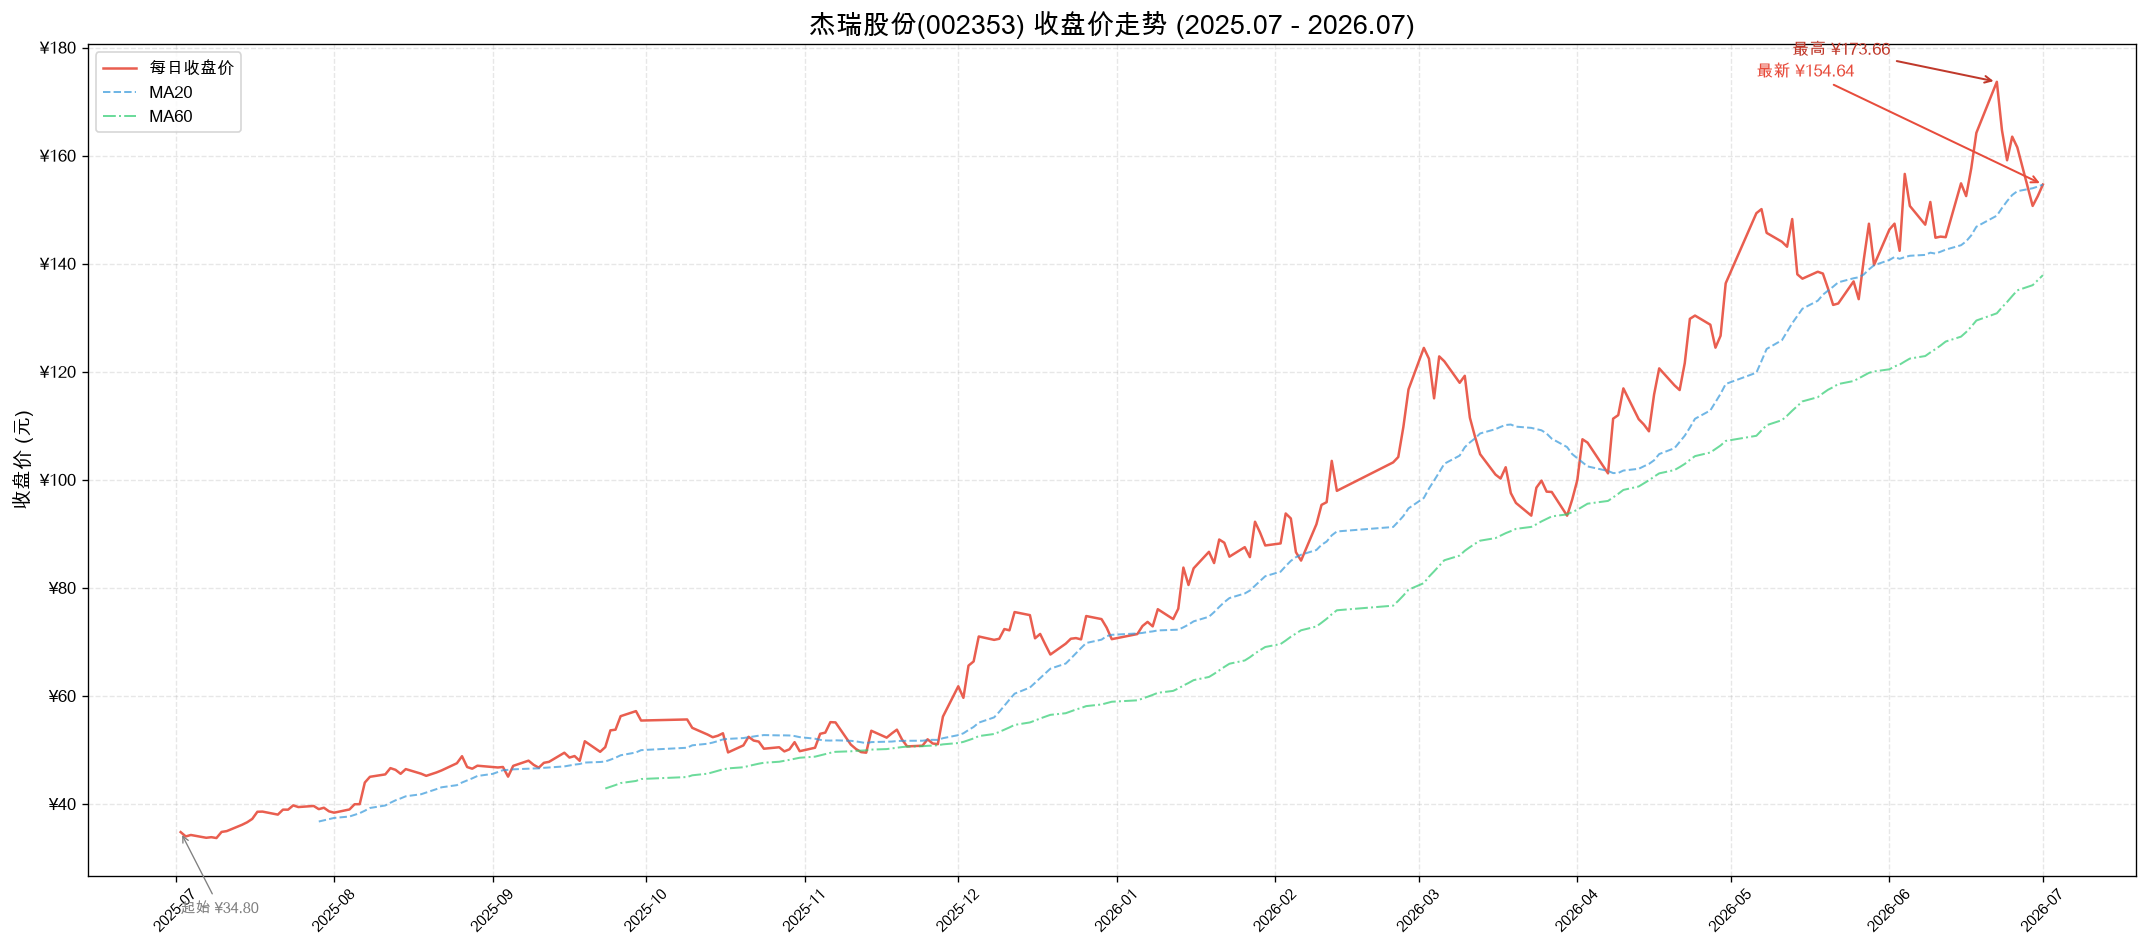

总涨幅: +344.43%


In [6]:
fig, ax = plt.subplots(figsize=(18, 8))

ax.plot(df.index, df['close'], color='#e74c3c', linewidth=1.5, label='每日收盘价', alpha=0.9)

ma20 = df['close'].rolling(20).mean()
ma60 = df['close'].rolling(60).mean()
ax.plot(df.index, ma20, color='#3498db', linewidth=1.2, linestyle='--', label='MA20', alpha=0.7)
ax.plot(df.index, ma60, color='#2ecc71', linewidth=1.2, linestyle='-.', label='MA60', alpha=0.7)

# 标注关键价格
start_price = df['close'].iloc[0]
end_price = df['close'].iloc[-1]
max_idx = df['close'].idxmax()

ax.annotate(f'起始 ¥{start_price:.2f}', xy=(df.index[0], start_price),
            xytext=(df.index[0], start_price - 15), fontsize=9, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
ax.annotate(f'最新 ¥{end_price:.2f}', xy=(df.index[-1], end_price),
            xytext=(df.index[-40], end_price + 20), fontsize=10, color='#e74c3c',
            fontweight='bold', arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2))
ax.annotate(f'最高 ¥{df["close"].max():.2f}', xy=(max_idx, df['close'].max()),
            xytext=(max_idx - pd.Timedelta(days=40), df['close'].max() + 5),
            fontsize=10, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, fontsize=9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x:.0f}'))
ax.set_title('杰瑞股份(002353) 收盘价走势 (2025.07 - 2026.07)', fontsize=16, fontweight='bold')
ax.set_ylabel('收盘价 (元)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
print(f'总涨幅: {total_pct:+.2f}%')

## 4. K线图（蜡烛图）

K线图是技术分析的核心，每根K线包含四个价格：
- **红色阳线**: 收盘价 ≥ 开盘价，上涨
- **绿色阴线**: 收盘价 < 开盘价，下跌

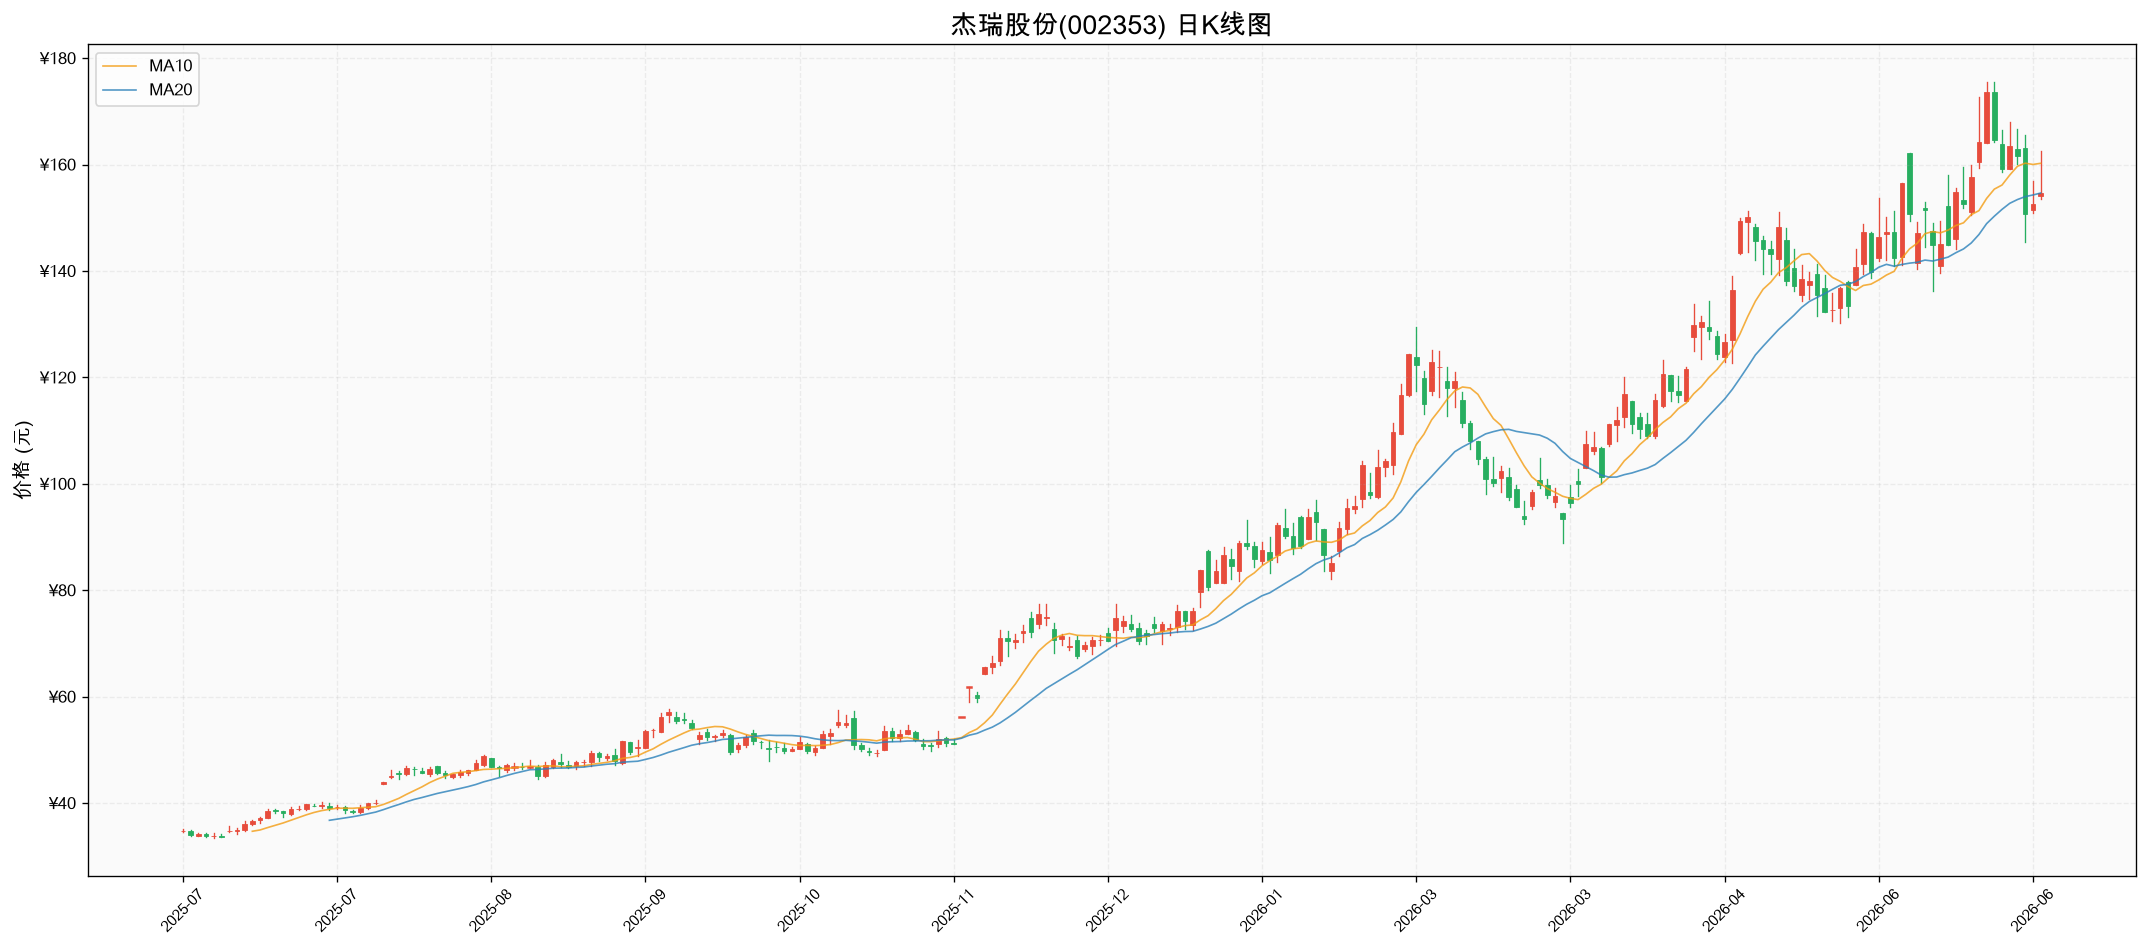

In [7]:
fig, ax = plt.subplots(figsize=(18, 8))
ax.set_facecolor('#fafafa')

width = 0.6
for i, (idx, row) in enumerate(df.iterrows()):
    is_up = row['close'] >= row['open']
    color = '#e74c3c' if is_up else '#27ae60'
    ax.plot([i, i], [row['low'], row['high']], color=color, linewidth=0.8)
    body_bottom = row['open'] if is_up else row['close']
    body_height = abs(row['close'] - row['open'])
    if body_height > 0:
        rect = Rectangle((i - width/2, body_bottom), width, body_height,
                         facecolor=color, edgecolor=color, linewidth=0.5)
        ax.add_patch(rect)
    else:
        ax.plot([i - width/2, i + width/2], [row['close'], row['close']],
               color=color, linewidth=1.5)

x_vals = range(len(df))
ma10 = df['close'].rolling(10).mean()
ax.plot(x_vals, ma10.values, color='#f39c12', linewidth=1.0, label='MA10', alpha=0.8)
ma20 = df['close'].rolling(20).mean()
ax.plot(x_vals, ma20.values, color='#2980b9', linewidth=1.0, label='MA20', alpha=0.8)

n = len(df)
tick_positions = list(range(0, n, max(1, n // 12)))
tick_labels = [df.index[p].strftime('%Y-%m') for p in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, fontsize=9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x:.0f}'))
ax.set_title('杰瑞股份(002353) 日K线图', fontsize=16, fontweight='bold')
ax.set_ylabel('价格 (元)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

## 5. 成交量分析

findfont: Failed to find font weight bold, now using 400.


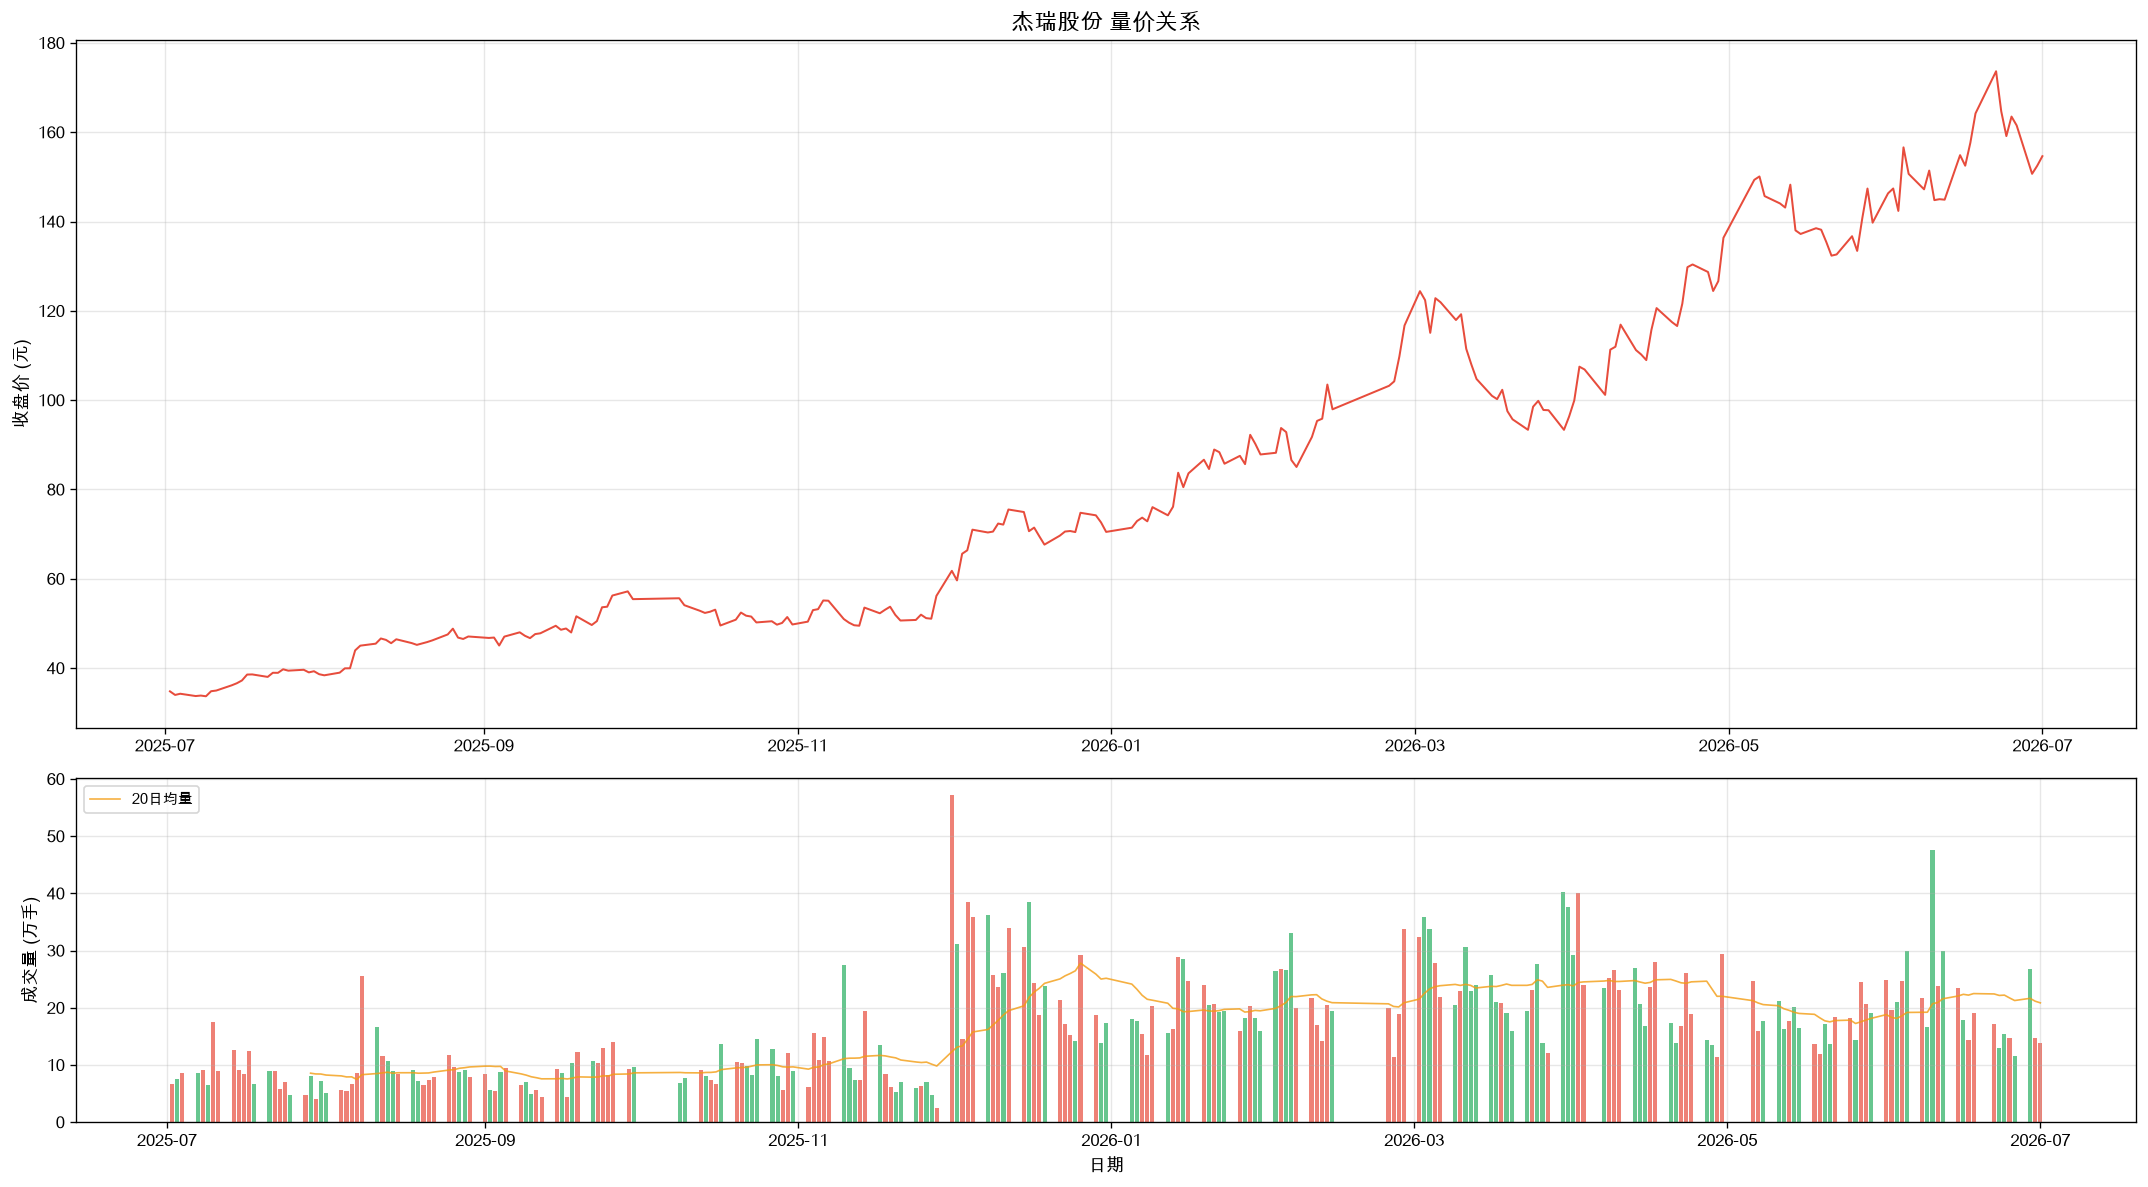

日均成交量: 17 万手
最大成交量: 57 万手 (2025-12-01)
最小成交量: 2 万手 (2025-11-28)


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(df.index, df['close'], color='#e74c3c', linewidth=1.2)
ax1.set_ylabel('收盘价 (元)', fontsize=11)
ax1.set_title('杰瑞股份 量价关系', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

colors = ['#e74c3c' if c >= o else '#27ae60' for c, o in zip(df['close'], df['open'])]
ax2.bar(df.index, df['vol']/10000, color=colors, width=0.8, alpha=0.7)
ax2.set_ylabel('成交量 (万手)', fontsize=11)
ax2.set_xlabel('日期', fontsize=11)
ax2.grid(True, alpha=0.3)

vol_ma = df['vol'].rolling(20).mean() / 10000
ax2.plot(df.index, vol_ma, color='#f39c12', linewidth=1.0, label='20日均量', alpha=0.8)
ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()
print(f'日均成交量: {df["vol"].mean()/10000:.0f} 万手')
print(f'最大成交量: {df["vol"].max()/10000:.0f} 万手 ({df["vol"].idxmax().strftime("%Y-%m-%d")})')
print(f'最小成交量: {df["vol"].min()/10000:.0f} 万手 ({df["vol"].idxmin().strftime("%Y-%m-%d")})')

## 6. 收益率分析

In [9]:
df['ret'] = df['close'].pct_change()

ret = df['ret'].dropna()
print('=== 日收益率统计 ===')
print(f'均值: {ret.mean()*100:.4f}%')
print(f'标准差: {ret.std()*100:.4f}%')
print(f'偏度: {ret.skew():.4f}')
print(f'峰度: {ret.kurtosis():.4f}')
print(f'最大值: {ret.max()*100:.2f}% ({ret.idxmax().strftime("%Y-%m-%d")})')
print(f'最小值: {ret.min()*100:.2f}% ({ret.idxmin().strftime("%Y-%m-%d")})')
print(f'上涨天数: {(ret > 0).sum()} ({(ret > 0).mean()*100:.1f}%)')
print(f'下跌天数: {(ret < 0).sum()} ({(ret < 0).mean()*100:.1f}%)')

=== 日收益率统计 ===
均值: 0.6866%
标准差: 3.6659%
偏度: 0.4905
峰度: 0.1368
最大值: 10.01% (2025-08-07)
最小值: -7.46% (2025-11-10)
上涨天数: 130 (53.9%)
下跌天数: 111 (46.1%)


findfont: Failed to find font weight bold, now using 400.


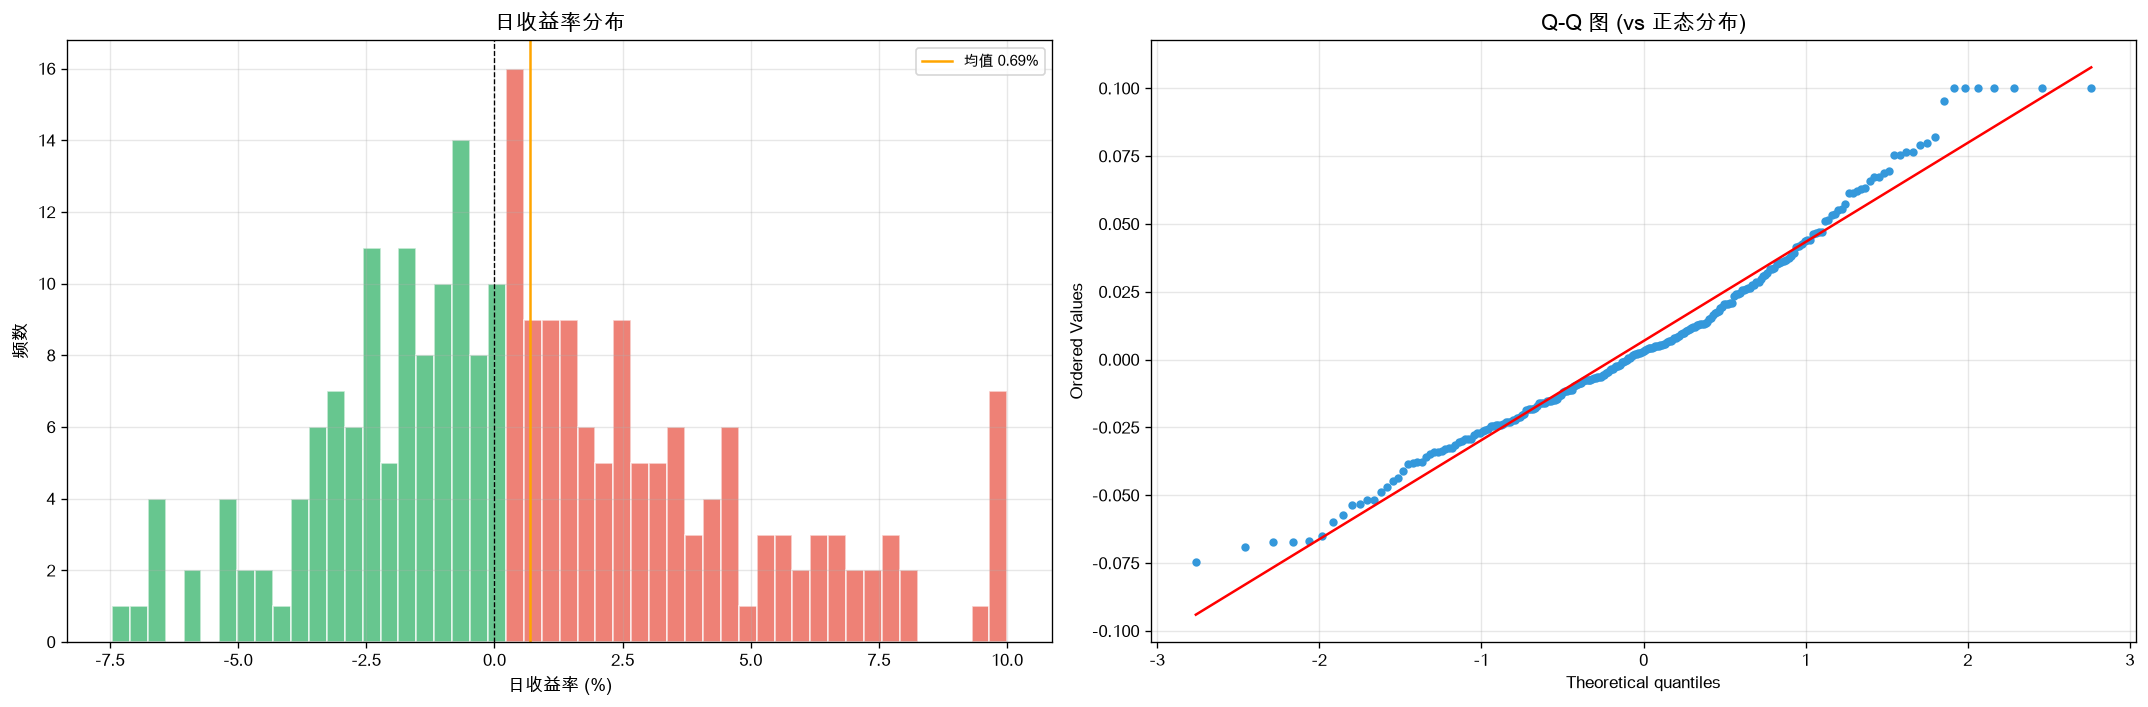

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
n, bins, patches = ax.hist(ret * 100, bins=50, alpha=0.7, color='#3498db', edgecolor='white')
for i, (b, patch) in enumerate(zip(bins[:-1], patches)):
    patch.set_facecolor('#e74c3c' if b >= 0 else '#27ae60')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(x=ret.mean()*100, color='orange', linewidth=1.5, label=f'均值 {ret.mean()*100:.2f}%')
ax.set_xlabel('日收益率 (%)', fontsize=11)
ax.set_ylabel('频数', fontsize=11)
ax.set_title('日收益率分布', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
stats.probplot(ret.dropna(), dist='norm', plot=ax)
ax.get_lines()[0].set_markerfacecolor('#3498db')
ax.get_lines()[0].set_markeredgecolor('#3498db')
ax.get_lines()[0].set_markersize(4)
ax.set_title('Q-Q 图 (vs 正态分布)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 累计收益

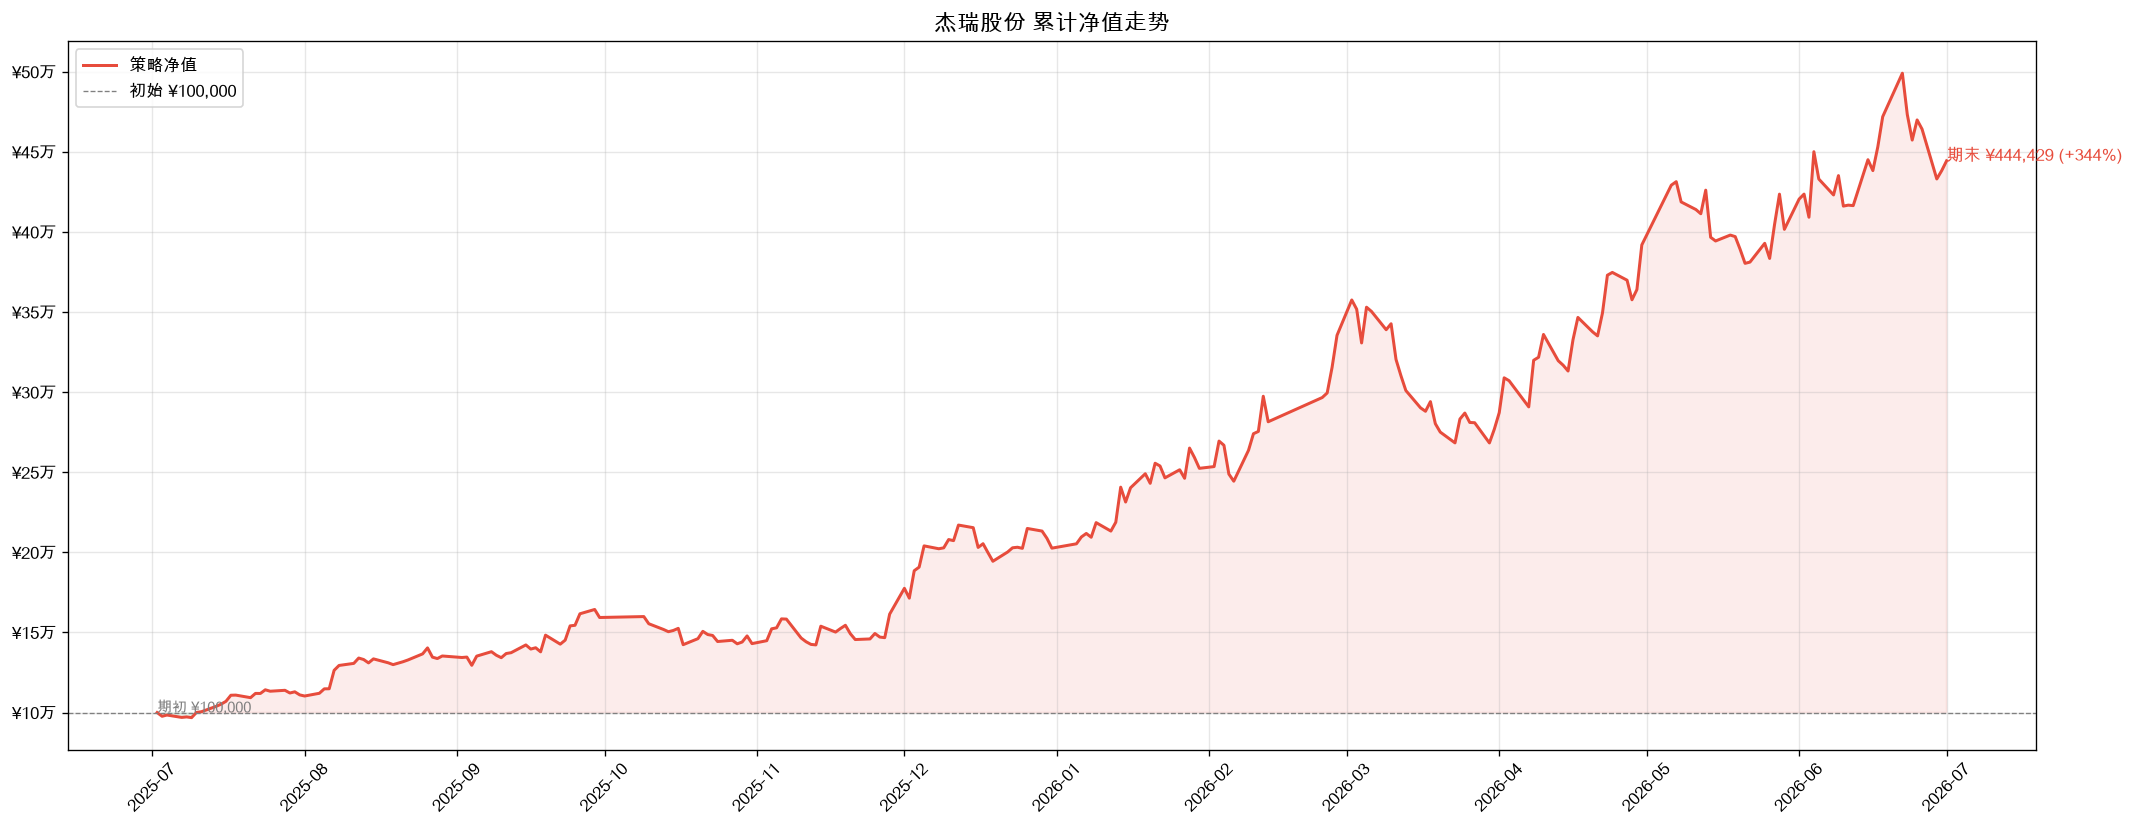

💰 初始: ¥100,000  →  期末: ¥444,429  |  收益: ¥344,429


In [11]:
initial_capital = 100000
df['cum_ret'] = (1 + df['ret'].fillna(0)).cumprod()
df['equity'] = initial_capital * df['cum_ret']

final_value = df['equity'].iloc[-1]

fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(df.index, df['equity'], color='#e74c3c', linewidth=1.8, label='策略净值')
ax.axhline(y=initial_capital, color='gray', linewidth=0.8, linestyle='--', label='初始 ¥100,000')
ax.fill_between(df.index, initial_capital, df['equity'],
                where=(df['equity'] >= initial_capital), color='#e74c3c', alpha=0.1)
ax.fill_between(df.index, initial_capital, df['equity'],
                where=(df['equity'] < initial_capital), color='#27ae60', alpha=0.1)

ax.annotate(f'期初 ¥{initial_capital:,.0f}', xy=(df.index[0], initial_capital), fontsize=9, color='gray')
ax.annotate(f'期末 ¥{final_value:,.0f} (+{(final_value/initial_capital-1)*100:.0f}%)',
            xy=(df.index[-1], final_value), fontsize=10, color='#e74c3c', fontweight='bold')

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x/10000:.0f}万'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.set_title('杰瑞股份 累计净值走势', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'💰 初始: ¥{initial_capital:,.0f}  →  期末: ¥{final_value:,.0f}  |  收益: ¥{final_value-initial_capital:,.0f}')

## 8. 三阶段走势分析

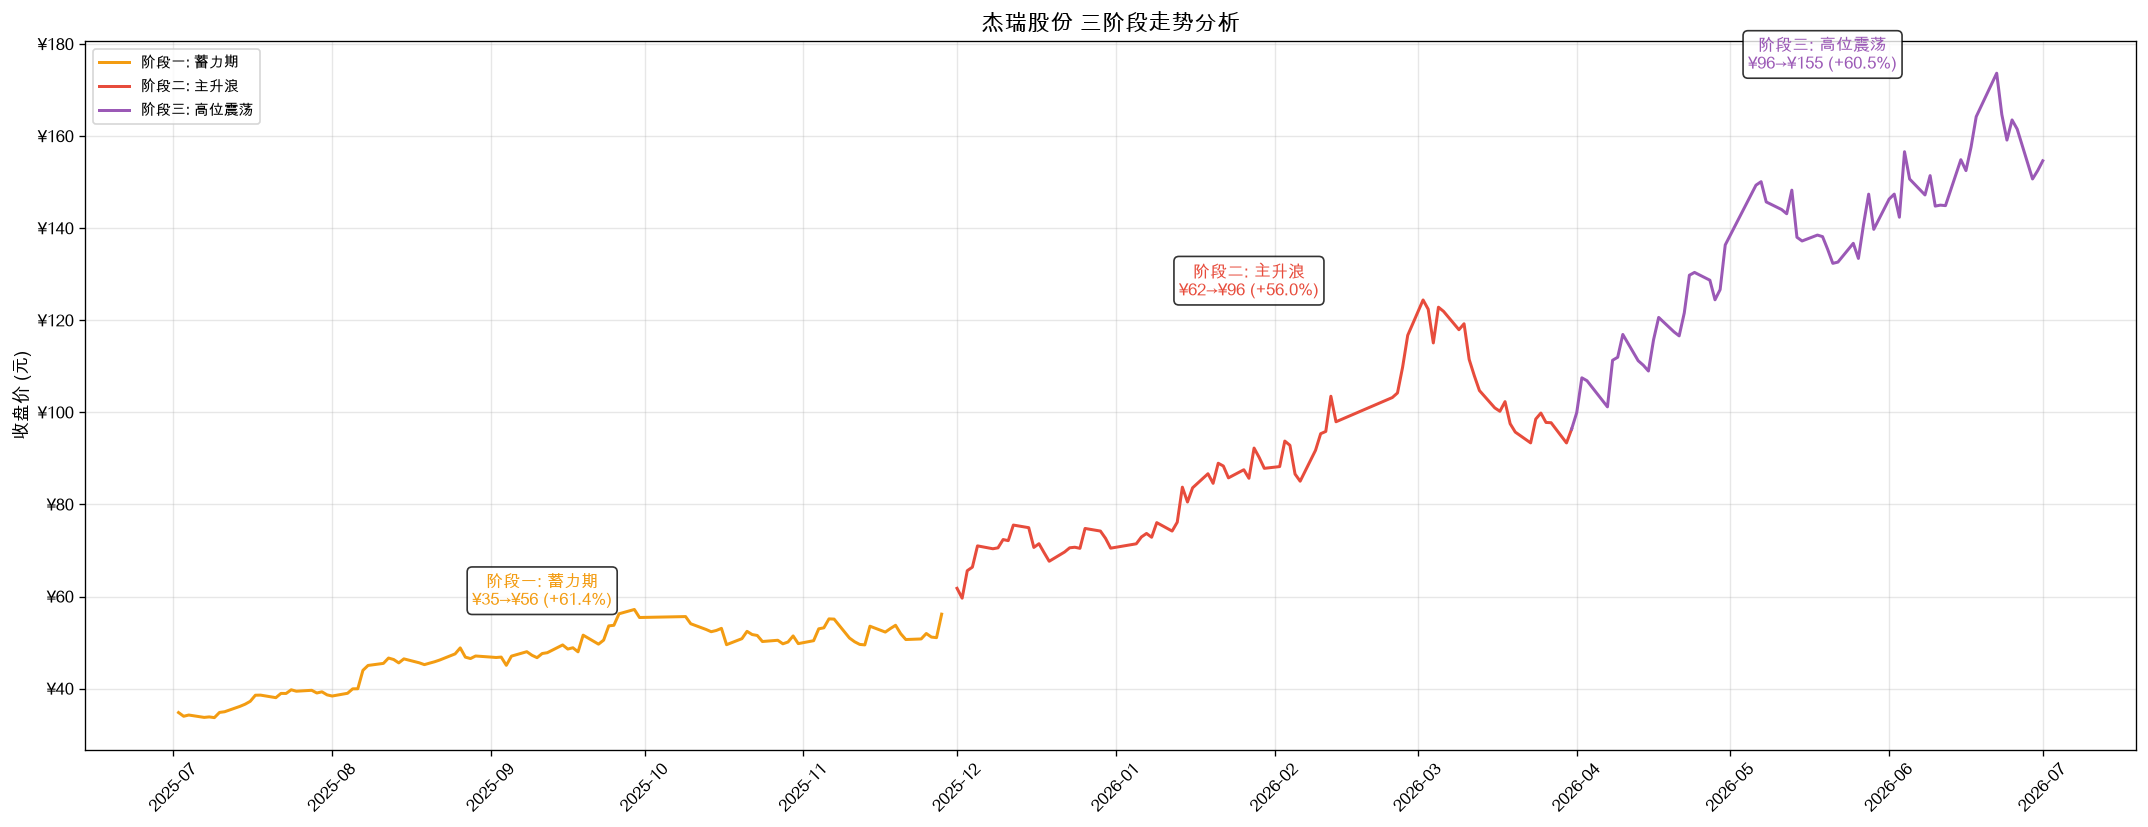

阶段一: 蓄力期: ¥34.80→¥56.17 (+61.43%) | 波动率2.88% | 102日
阶段二: 主升浪: ¥61.78→¥96.35 (+55.95%) | 波动率4.14% | 79日
阶段三: 高位震荡: ¥96.35→¥154.64 (+60.49%) | 波动率4.17% | 62日


In [12]:
phases = {
    '阶段一: 蓄力期': ('2025-07-02', '2025-11-30'),
    '阶段二: 主升浪': ('2025-11-30', '2026-03-31'),
    '阶段三: 高位震荡': ('2026-03-31', '2026-07-01')
}
cp = {'阶段一: 蓄力期': '#f39c12', '阶段二: 主升浪': '#e74c3c', '阶段三: 高位震荡': '#9b59b6'}

fig, ax = plt.subplots(figsize=(18, 7))
for name, (s, e) in phases.items():
    sub = df.loc[s:e]
    ax.plot(sub.index, sub['close'], color=cp[name], linewidth=1.8, label=name)
    s_price, e_price = sub['close'].iloc[0], sub['close'].iloc[-1]
    r = (e_price/s_price - 1)*100
    mid = sub.index[len(sub)//2]
    ax.annotate(f'{name}\n¥{s_price:.0f}→¥{e_price:.0f} ({r:+.1f}%)',
                xy=(mid, sub['close'].max()), fontsize=10, color=cp[name],
                fontweight='bold', ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x:.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.set_title('杰瑞股份 三阶段走势分析', fontsize=14, fontweight='bold')
ax.set_ylabel('收盘价 (元)', fontsize=11)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for name, (s, e) in phases.items():
    sub = df.loc[s:e]
    r = (sub['close'].iloc[-1]/sub['close'].iloc[0]-1)*100
    vol = sub['ret'].std()*100
    print(f'{name}: ¥{sub["close"].iloc[0]:.2f}→¥{sub["close"].iloc[-1]:.2f} ({r:+.2f}%) | 波动率{vol:.2f}% | {len(sub)}日')

## 9. 月度收益分析

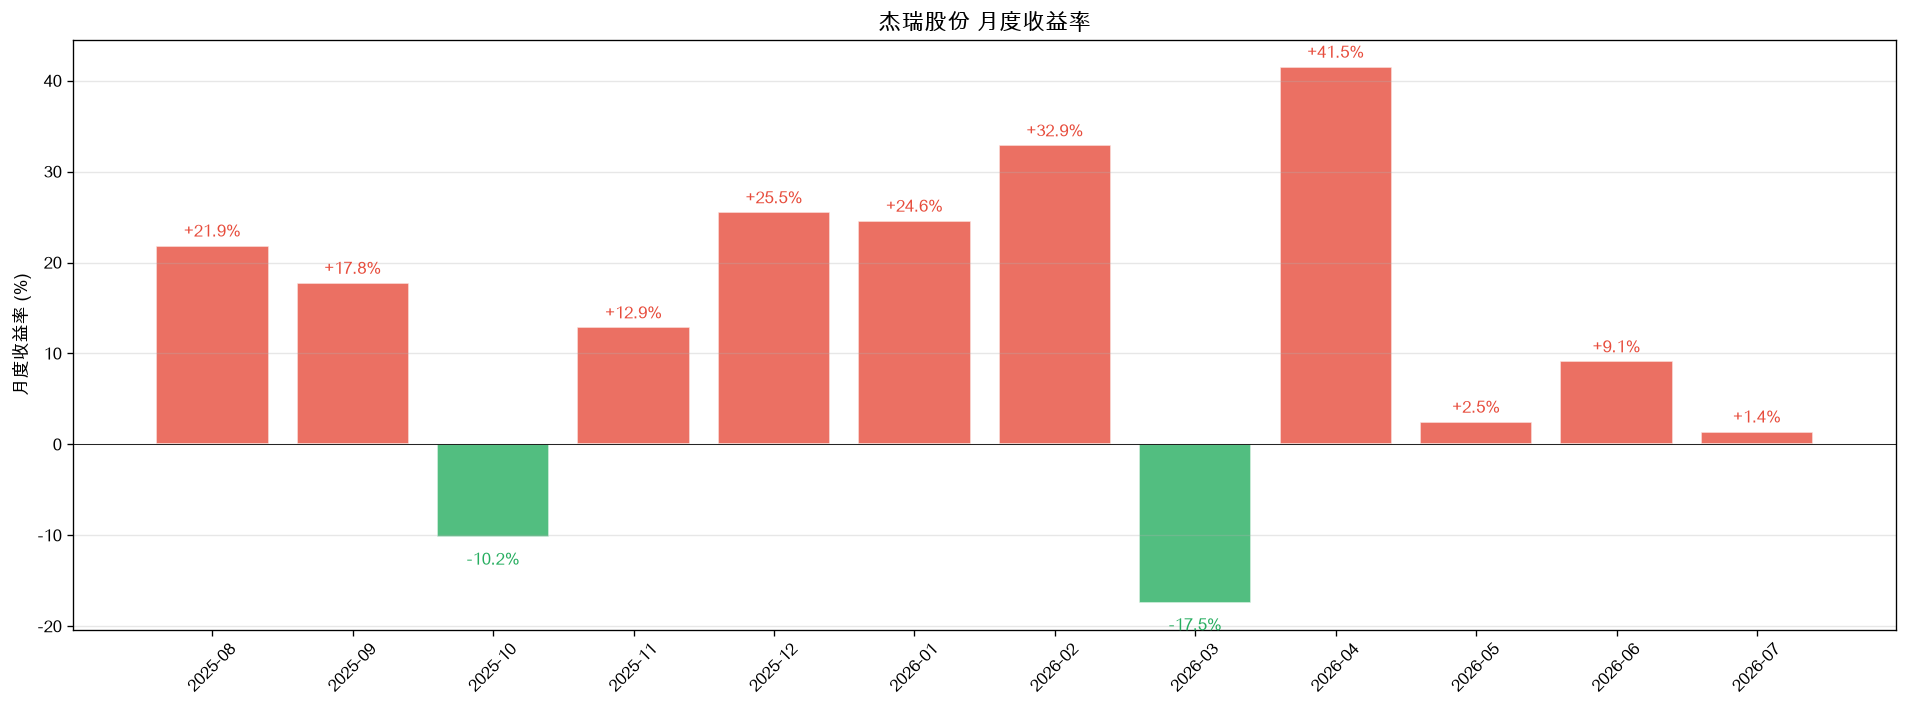

月胜率: 10/12 = 83%
最佳月: 2026-04 (+41.53%)
最差月: 2026-03 (-17.46%)
月均收益: 13.53%


In [13]:
monthly = df['close'].resample('ME').last()
monthly_ret = monthly.pct_change().dropna()

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['#e74c3c' if r > 0 else '#27ae60' for r in monthly_ret]
ax.bar(range(len(monthly_ret)), monthly_ret * 100, color=colors, alpha=0.8, edgecolor='white')
for i, (idx, r) in enumerate(monthly_ret.items()):
    ax.text(i, r*100+(1 if r>0 else -3), f'{r*100:+.1f}%', ha='center',
            fontsize=10, fontweight='bold', color='#e74c3c' if r>0 else '#27ae60')
ax.set_xticks(range(len(monthly_ret)))
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly_ret.index], rotation=45)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('杰瑞股份 月度收益率', fontsize=14, fontweight='bold')
ax.set_ylabel('月度收益率 (%)', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

win = (monthly_ret > 0).sum()
print(f'月胜率: {win}/{len(monthly_ret)} = {win/len(monthly_ret)*100:.0f}%')
print(f'最佳月: {monthly_ret.idxmax().strftime("%Y-%m")} ({monthly_ret.max()*100:+.2f}%)')
print(f'最差月: {monthly_ret.idxmin().strftime("%Y-%m")} ({monthly_ret.min()*100:+.2f}%)')
print(f'月均收益: {monthly_ret.mean()*100:.2f}%')

## 10. 风险收益指标

包括夏普比率、最大回撤、盈亏比、卡尔玛比率等。

In [14]:
trading_days = 252
risk_free = 0.02

total_return = df['close'].iloc[-1] / df['close'].iloc[0] - 1
annual_return = (1 + total_return) ** (trading_days / len(df)) - 1
daily_vol = df['ret'].std()
annual_vol = daily_vol * np.sqrt(trading_days)
sharpe = (annual_return - risk_free) / annual_vol

cummax = df['close'].cummax()
drawdown = (df['close'] - cummax) / cummax
max_dd = drawdown.min()
max_dd_date = drawdown.idxmin()

up_ret = df.loc[df['ret'] > 0, 'ret']
down_ret = df.loc[df['ret'] < 0, 'ret']
wlr = up_ret.mean() / abs(down_ret.mean())

# 最大连涨/连跌
max_up = max_down = cur = 0
for r in df['ret'].dropna():
    if r > 0:
        cur = max(1, cur+1) if cur>0 else 1
        max_up = max(max_up, cur)
    else:
        cur = min(-1, cur-1) if cur<0 else -1
        max_down = min(max_down, cur)

print('='*50)
print('  杰瑞股份 风险收益指标')
print('='*50)
print(f'总收益率:    {total_return*100:+.2f}%')
print(f'年化收益率:  {annual_return*100:+.2f}%')
print(f'年化波动率:  {annual_vol*100:.2f}%')
print(f'夏普比率:    {sharpe:.2f}')
print(f'最大回撤:    {max_dd*100:.2f}% ({max_dd_date.strftime("%Y-%m-%d")})')
print(f'盈亏比:      {wlr:.2f}')
print(f'最大连涨:    {max_up} 天')
print(f'最大连跌:    {abs(max_down)} 天')
print(f'卡尔玛比率:  {annual_return/abs(max_dd):.2f}')

  杰瑞股份 风险收益指标
总收益率:    +344.43%
年化收益率:  +372.68%
年化波动率:  58.19%
夏普比率:    6.37
最大回撤:    -24.96% (2026-03-30)
盈亏比:      1.40
最大连涨:    7 天
最大连跌:    5 天
卡尔玛比率:  14.93


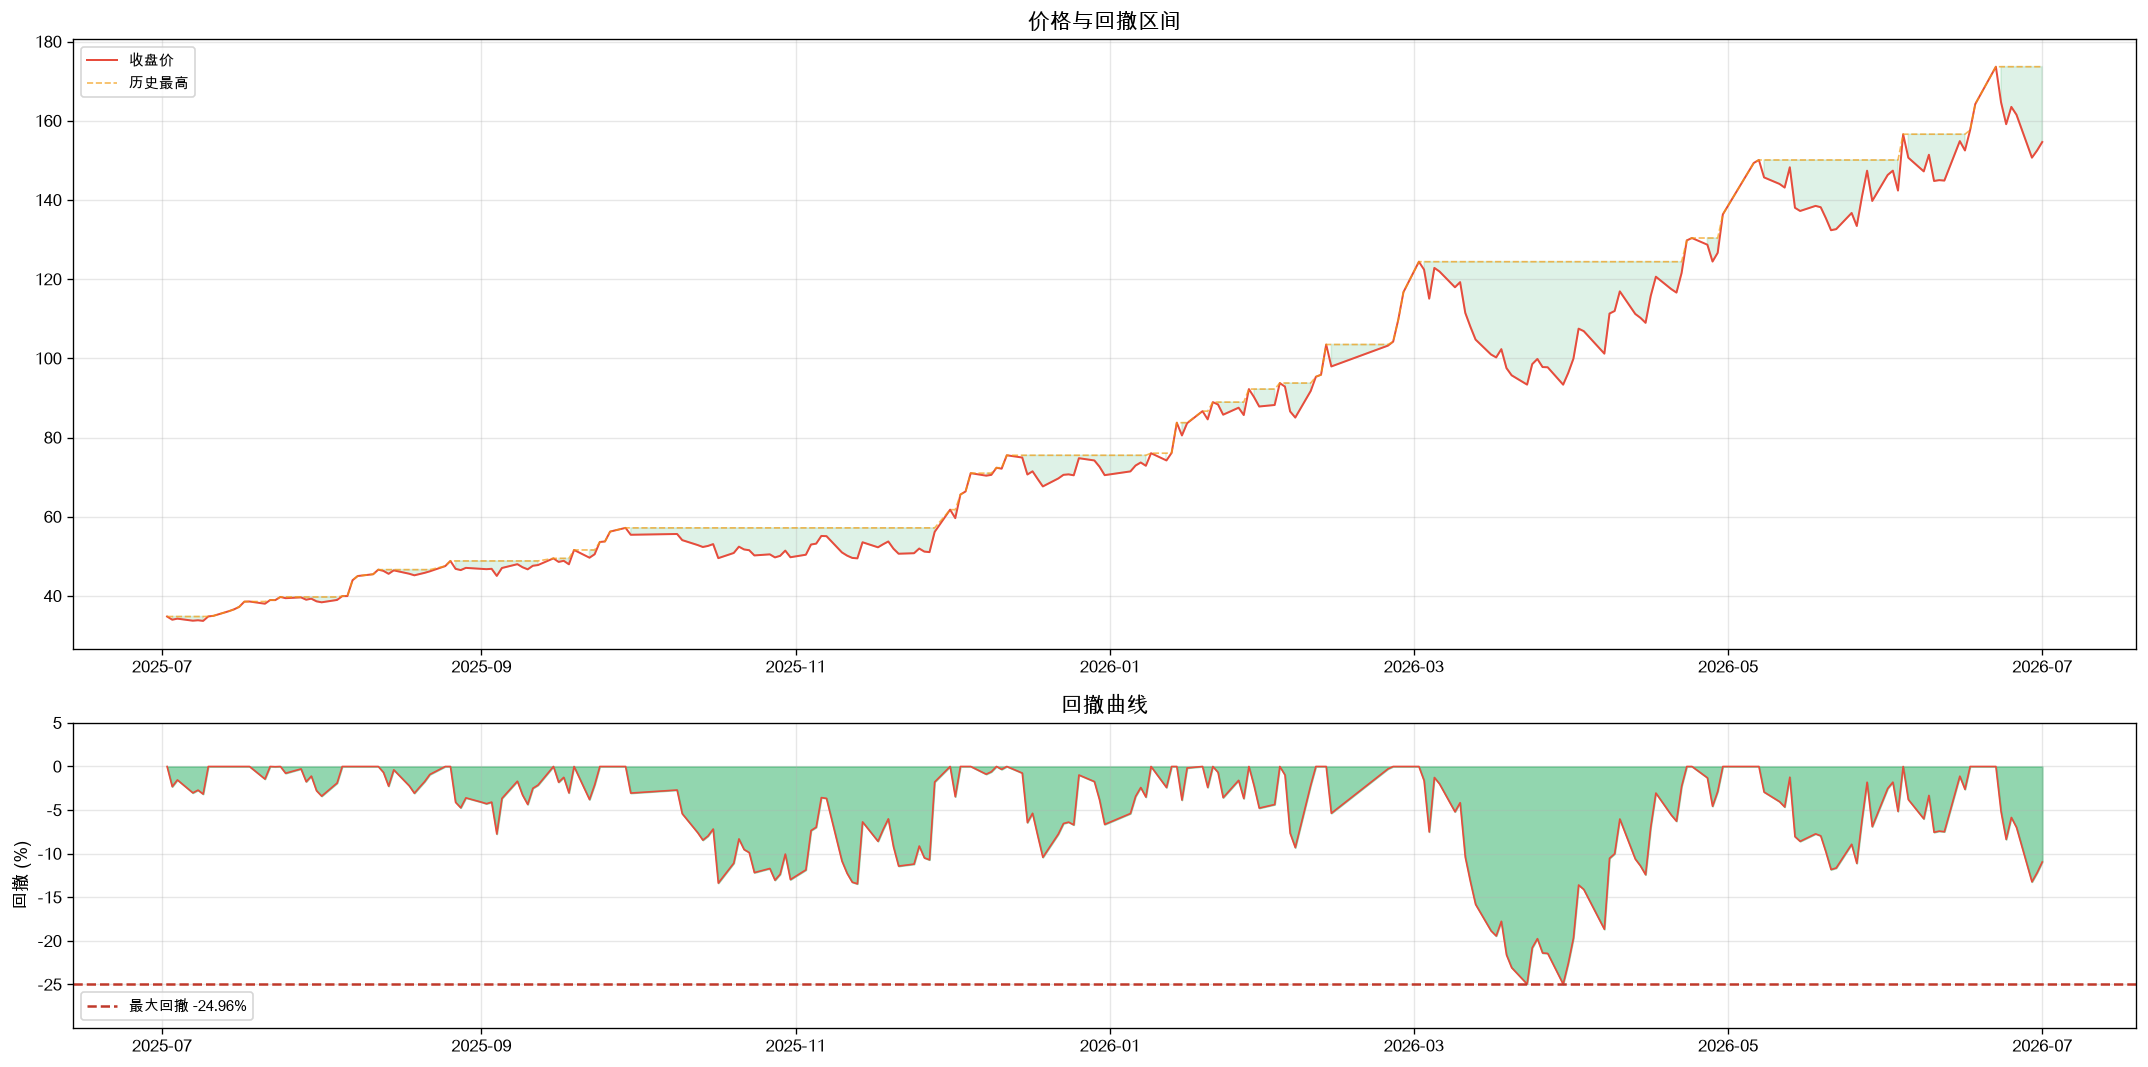

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(18, 9), gridspec_kw={'height_ratios': [2, 1]})
axes[0].plot(df.index, df['close'], color='#e74c3c', linewidth=1.2, label='收盘价')
axes[0].plot(df.index, cummax, color='#f39c12', linewidth=1.0, linestyle='--', label='历史最高', alpha=0.7)
axes[0].fill_between(df.index, df['close'], cummax, where=(df['close']<cummax), color='#27ae60', alpha=0.15)
axes[0].set_title('价格与回撤区间', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(df.index, 0, drawdown*100, color='#27ae60', alpha=0.5)
axes[1].plot(df.index, drawdown*100, color='#e74c3c', linewidth=1.0)
axes[1].axhline(y=max_dd*100, color='#c0392b', linewidth=1.5, linestyle='--', label=f'最大回撤 {max_dd*100:.2f}%')
axes[1].set_title('回撤曲线', fontsize=13, fontweight='bold')
axes[1].set_ylabel('回撤 (%)', fontsize=11)
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(drawdown.min()*100*1.2, 5)
plt.tight_layout()
plt.show()

## 11. 滚动波动率

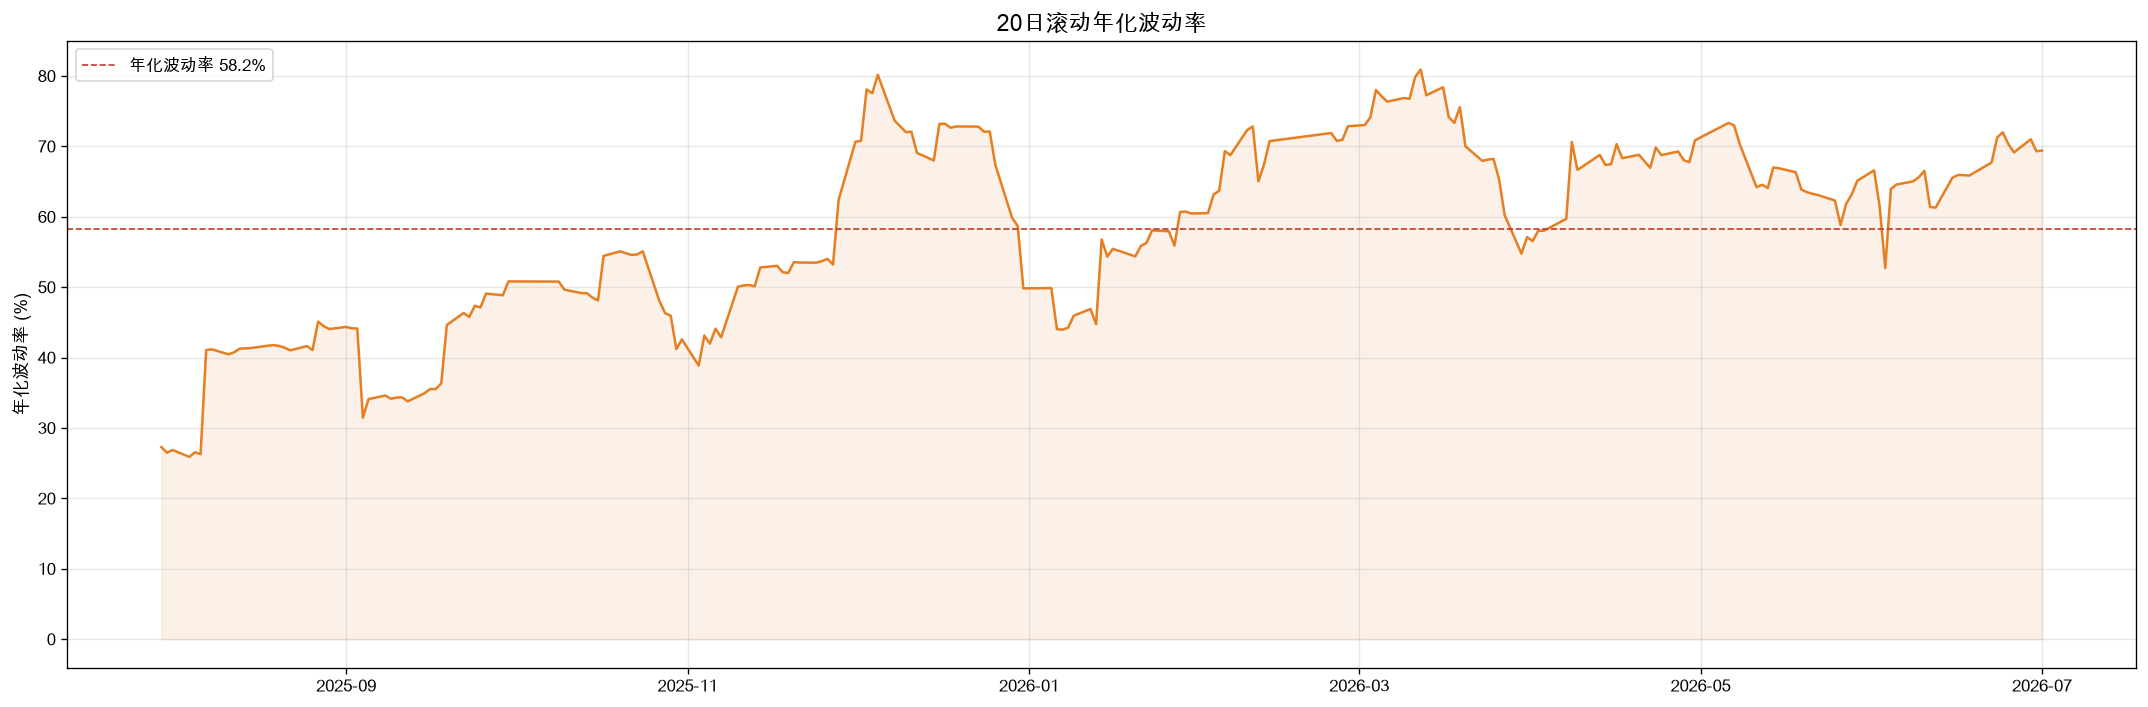

平均滚动波动率: 58.0%  |  最高: 80.9%  |  最低: 25.9%


In [16]:
df['rolling_vol'] = df['ret'].rolling(20).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(df.index, df['rolling_vol'], color='#e67e22', linewidth=1.5)
ax.fill_between(df.index, 0, df['rolling_vol'], color='#e67e22', alpha=0.1)
ax.axhline(y=annual_vol*100, color='#c0392b', linewidth=1.0, linestyle='--', label=f'年化波动率 {annual_vol*100:.1f}%')
ax.set_title('20日滚动年化波动率', fontsize=14, fontweight='bold')
ax.set_ylabel('年化波动率 (%)', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'平均滚动波动率: {df["rolling_vol"].mean():.1f}%  |  最高: {df["rolling_vol"].max():.1f}%  |  最低: {df["rolling_vol"].min():.1f}%')

## 12. 技术指标：RSI (相对强弱指标)

### 理论
$$
RS = \frac{\text{周期内平均涨幅}}{\text{周期内平均跌幅}} \qquad
RSI = 100 - \frac{100}{1 + RS}
$$

- **参数**: 通常取 14 日
- **超买超卖**: RSI > 70 超买(可能回调), RSI < 30 超卖(可能反弹)
- **趋势判断**: RSI > 50 多头主导, RSI < 50 空头主导
- **背离信号**: 价格新高而RSI未新高 → 顶背离(看跌); 反之底背离(看涨)

In [17]:
def calc_rsi(close, period=14):
    """Wilder平滑方法计算RSI"""
    delta = close.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = (-delta).where(delta < 0, 0.0)
    
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    
    for i in range(period, len(avg_gain)):
        avg_gain.iloc[i] = (avg_gain.iloc[i-1] * (period-1) + gain.iloc[i]) / period
        avg_loss.iloc[i] = (avg_loss.iloc[i-1] * (period-1) + loss.iloc[i]) / period
    
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['rsi_14'] = calc_rsi(df['close'], 14)
print(f'RSI(14) 最新值: {df["rsi_14"].iloc[-1]:.2f}')
print(f'超买天数: {(df["rsi_14"] > 70).sum()} 天 ({(df["rsi_14"] > 70).mean()*100:.1f}%)')
print(f'超卖天数: {(df["rsi_14"] < 30).sum()} 天 ({(df["rsi_14"] < 30).mean()*100:.1f}%)')

RSI(14) 最新值: 52.53
超买天数: 44 天 (18.2%)
超卖天数: 0 天 (0.0%)


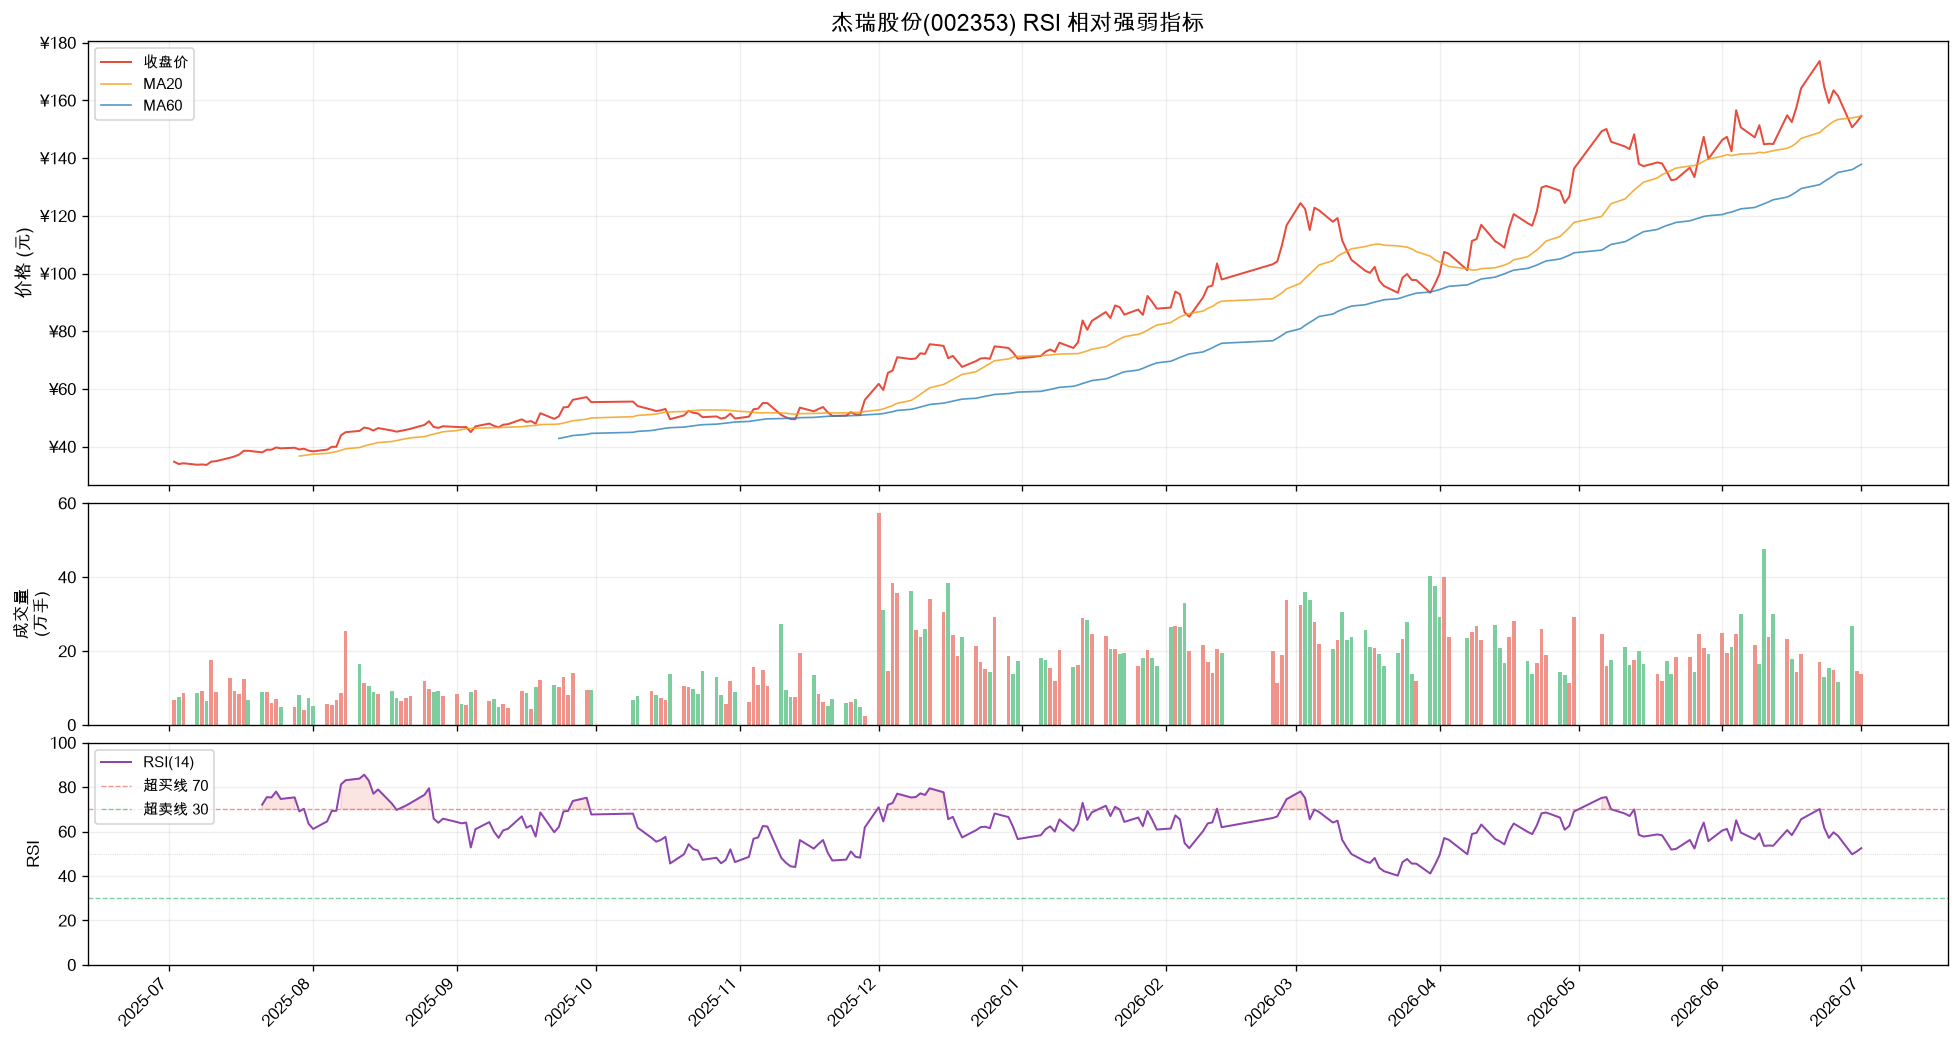

In [18]:
fig = plt.figure(figsize=(20, 10))
gs = GridSpec(3, 1, figure=fig, height_ratios=[2, 1, 1], hspace=0.06)

ax1 = fig.add_subplot(gs[0])
ax1.plot(df.index, df['close'], color='#e74c3c', linewidth=1.2, label='收盘价')
ax1.plot(df.index, df['close'].rolling(20).mean(), color='#f39c12', linewidth=1.0, alpha=0.8, label='MA20')
ax1.plot(df.index, df['close'].rolling(60).mean(), color='#2980b9', linewidth=1.0, alpha=0.8, label='MA60')
ax1.set_ylabel('价格 (元)', fontsize=11)
ax1.set_title('杰瑞股份(002353) RSI 相对强弱指标', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.2)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x:.0f}'))
ax1.tick_params(labelbottom=False)

ax2 = fig.add_subplot(gs[1], sharex=ax1)
colors_v = ['#e74c3c' if c >= o else '#27ae60' for c, o in zip(df['close'], df['open'])]
ax2.bar(df.index, df['vol']/10000, color=colors_v, width=0.8, alpha=0.6)
ax2.set_ylabel('成交量\n(万手)', fontsize=10)
ax2.grid(True, alpha=0.2)
ax2.tick_params(labelbottom=False)

ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(df.index, df['rsi_14'], color='#8e44ad', linewidth=1.2, label='RSI(14)')
ax3.axhline(y=70, color='#e74c3c', linewidth=0.8, linestyle='--', alpha=0.6, label='超买线 70')
ax3.axhline(y=30, color='#27ae60', linewidth=0.8, linestyle='--', alpha=0.6, label='超卖线 30')
ax3.axhline(y=50, color='gray', linewidth=0.5, linestyle=':', alpha=0.4)
ax3.fill_between(df.index, 70, df['rsi_14'], where=(df['rsi_14']>=70), color='#e74c3c', alpha=0.15)
ax3.fill_between(df.index, 30, df['rsi_14'], where=(df['rsi_14']<=30), color='#27ae60', alpha=0.15)
ax3.set_ylabel('RSI', fontsize=10)
ax3.set_ylim(0, 100)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.2)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.show()

## 13. 技术指标：MACD (指数平滑异同移动平均线)

### 理论
$$
DIF = EMA_{12}(close) - EMA_{26}(close) \\
DEA = EMA_{9}(DIF) \\
MACD柱 = 2 \times (DIF - DEA)
$$

- **金叉买入**: DIF线上穿 DEA 线
- **死叉卖出**: DIF线下穿 DEA 线
- **零轴判断**: DIF > 0 多头趋势, DIF < 0 空头趋势
- **背离信号**: 价格与 MACD 走势不一致预示反转

In [19]:
def calc_macd(close, fast=12, slow=26, signal=9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = 2 * (macd_line - signal_line)
    return macd_line, signal_line, histogram

df['macd'], df['macd_signal'], df['macd_hist'] = calc_macd(df['close'])

# 统计金叉死叉
golden = dead = 0
for i in range(1, len(df)):
    if df['macd'].iloc[i] > df['macd_signal'].iloc[i] and df['macd'].iloc[i-1] <= df['macd_signal'].iloc[i-1]:
        golden += 1
    if df['macd'].iloc[i] < df['macd_signal'].iloc[i] and df['macd'].iloc[i-1] >= df['macd_signal'].iloc[i-1]:
        dead += 1

print(f'MACD(12,26,9) 最新: DIF={df["macd"].iloc[-1]:.4f}, DEA={df["macd_signal"].iloc[-1]:.4f}, 柱={df["macd_hist"].iloc[-1]:.4f}')
print(f'金叉: {golden} 次, 死叉: {dead} 次')
print(f'零轴上方占比: {(df["macd"]>0).mean()*100:.1f}%')

MACD(12,26,9) 最新: DIF=4.5083, DEA=5.8303, 柱=-2.6439
金叉: 12 次, 死叉: 13 次
零轴上方占比: 92.6%


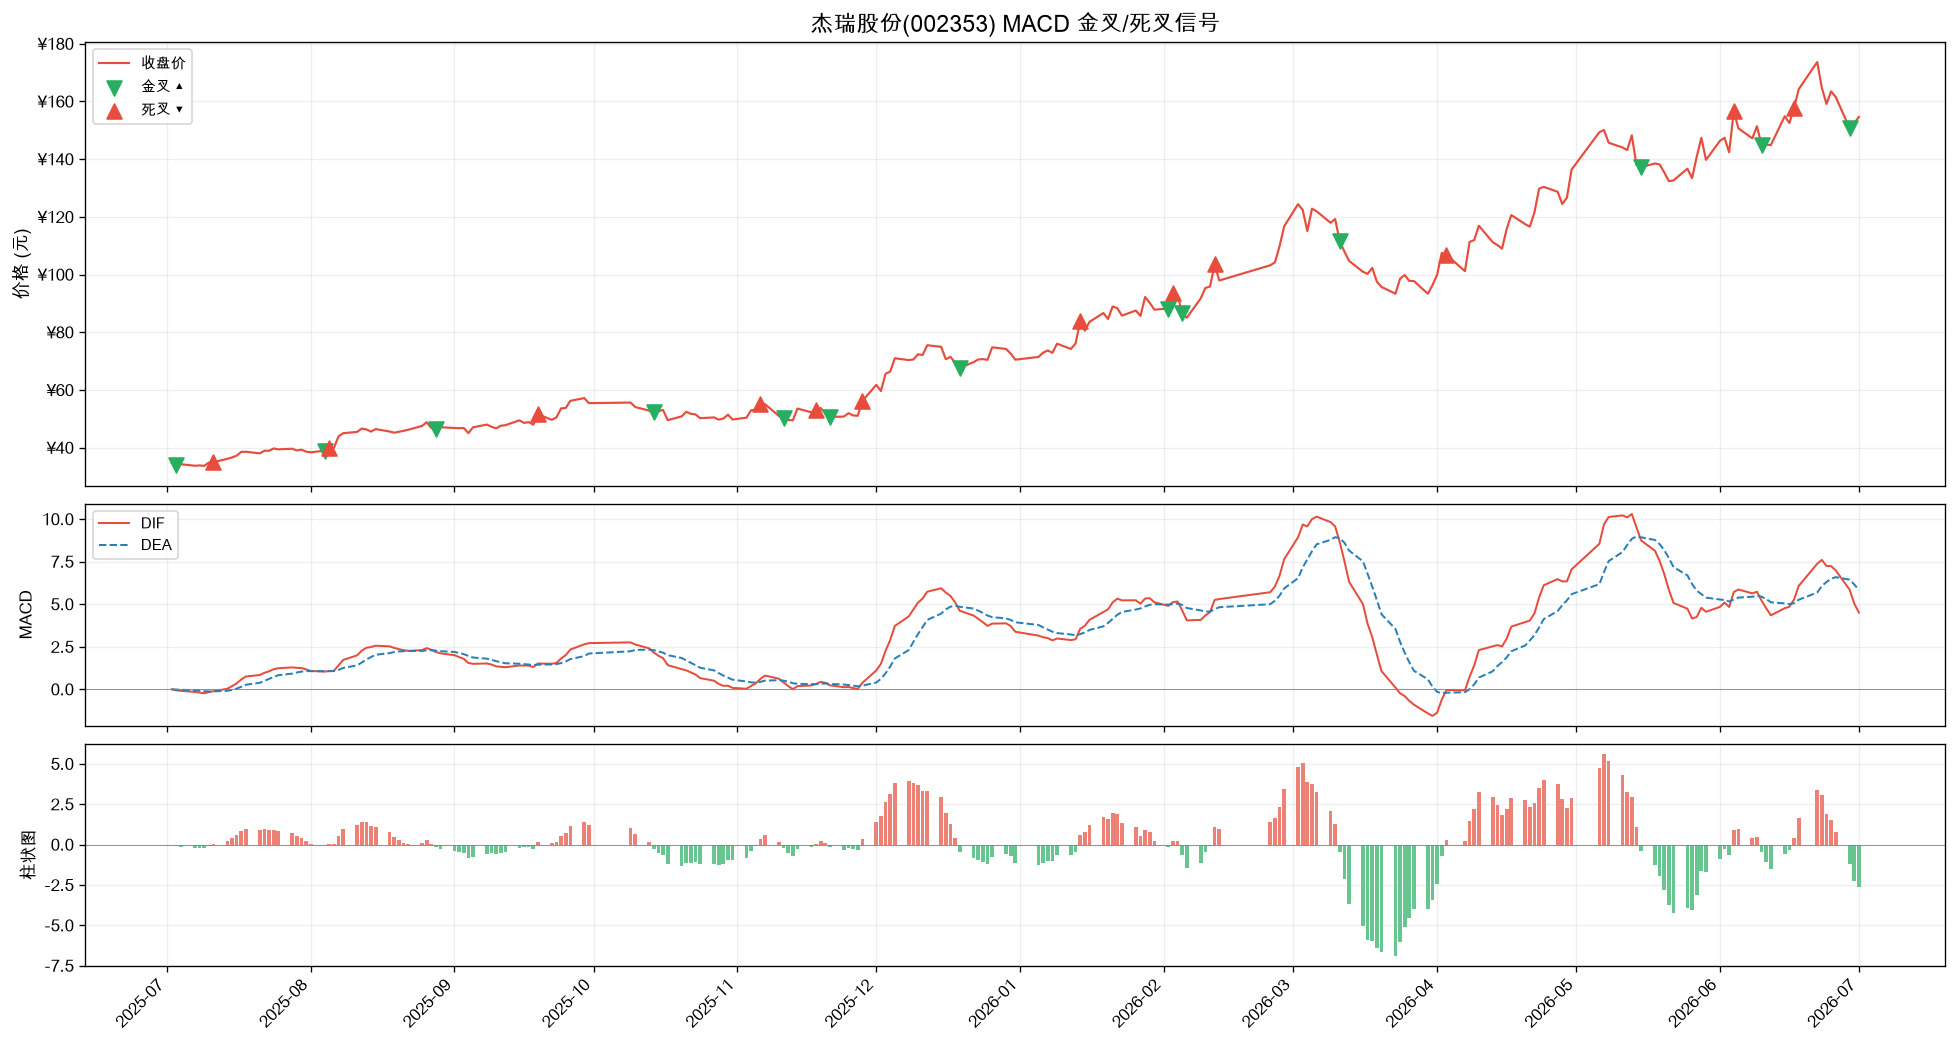

In [20]:
fig = plt.figure(figsize=(20, 10))
gs = GridSpec(3, 1, figure=fig, height_ratios=[2, 1, 1], hspace=0.06)

ax1 = fig.add_subplot(gs[0])
ax1.plot(df.index, df['close'], color='#e74c3c', linewidth=1.3, label='收盘价')
for i in range(1, len(df)):
    if df['macd'].iloc[i] > df['macd_signal'].iloc[i] and df['macd'].iloc[i-1] <= df['macd_signal'].iloc[i-1]:
        ax1.scatter(df.index[i], df['close'].iloc[i], marker='^', color='#e74c3c', s=80, zorder=5)
    if df['macd'].iloc[i] < df['macd_signal'].iloc[i] and df['macd'].iloc[i-1] >= df['macd_signal'].iloc[i-1]:
        ax1.scatter(df.index[i], df['close'].iloc[i], marker='v', color='#27ae60', s=80, zorder=5)
ax1.set_ylabel('价格 (元)', fontsize=11)
ax1.set_title('杰瑞股份(002353) MACD 金叉/死叉信号', fontsize=14, fontweight='bold')
ax1.legend(['收盘价', '金叉 ▲', '死叉 ▼'], loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.2)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x:.0f}'))
ax1.tick_params(labelbottom=False)

ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(df.index, df['macd'], color='#e74c3c', linewidth=1.2, label='DIF')
ax2.plot(df.index, df['macd_signal'], color='#2980b9', linewidth=1.2, label='DEA', linestyle='--')
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.set_ylabel('MACD', fontsize=10)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.2)
ax2.tick_params(labelbottom=False)

ax3 = fig.add_subplot(gs[2], sharex=ax1)
ch = ['#e74c3c' if v>=0 else '#27ae60' for v in df['macd_hist']]
ax3.bar(df.index, df['macd_hist'], color=ch, width=0.8, alpha=0.7)
ax3.axhline(y=0, color='gray', linewidth=0.5)
ax3.set_ylabel('柱状图', fontsize=10)
ax3.grid(True, alpha=0.2)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.show()

## 14. 技术指标：布林带 (Bollinger Bands)

### 理论
$$
中轨 = SMA_{20}(close) \\
上轨 = 中轨 + 2 \times \sigma_{20} \\
下轨 = 中轨 - 2 \times \sigma_{20}
$$

- **波动率测量**: 带宽反映市场波动程度
- **突破信号**: 价格触及上轨可能回调, 触下轨可能反弹
- **挤压信号**: 带宽收窄预示大幅波动即将来临
- **趋势跟随**: 价格沿某条轨道持续运行表示强趋势

In [21]:
def calc_bollinger(close, period=20, num_std=2):
    middle = close.rolling(window=period).mean()
    std = close.rolling(window=period).std()
    upper = middle + num_std * std
    lower = middle - num_std * std
    bandwidth = (upper - lower) / middle * 100
    percent_b = (close - lower) / (upper - lower)
    return upper, middle, lower, bandwidth, percent_b

df['bb_upper'], df['bb_middle'], df['bb_lower'], df['bb_width'], df['bb_pctb'] = calc_bollinger(df['close'])

print(f'布林带(20,2) 最新:')
print(f'  上轨 ¥{df["bb_upper"].iloc[-1]:.2f}  |  中轨 ¥{df["bb_middle"].iloc[-1]:.2f}  |  下轨 ¥{df["bb_lower"].iloc[-1]:.2f}')
print(f'  带宽 {df["bb_width"].iloc[-1]:.1f}%  |  %B {df["bb_pctb"].iloc[-1]:.3f}')

布林带(20,2) 最新:
  上轨 ¥170.88  |  中轨 ¥154.63  |  下轨 ¥138.38
  带宽 21.0%  |  %B 0.500


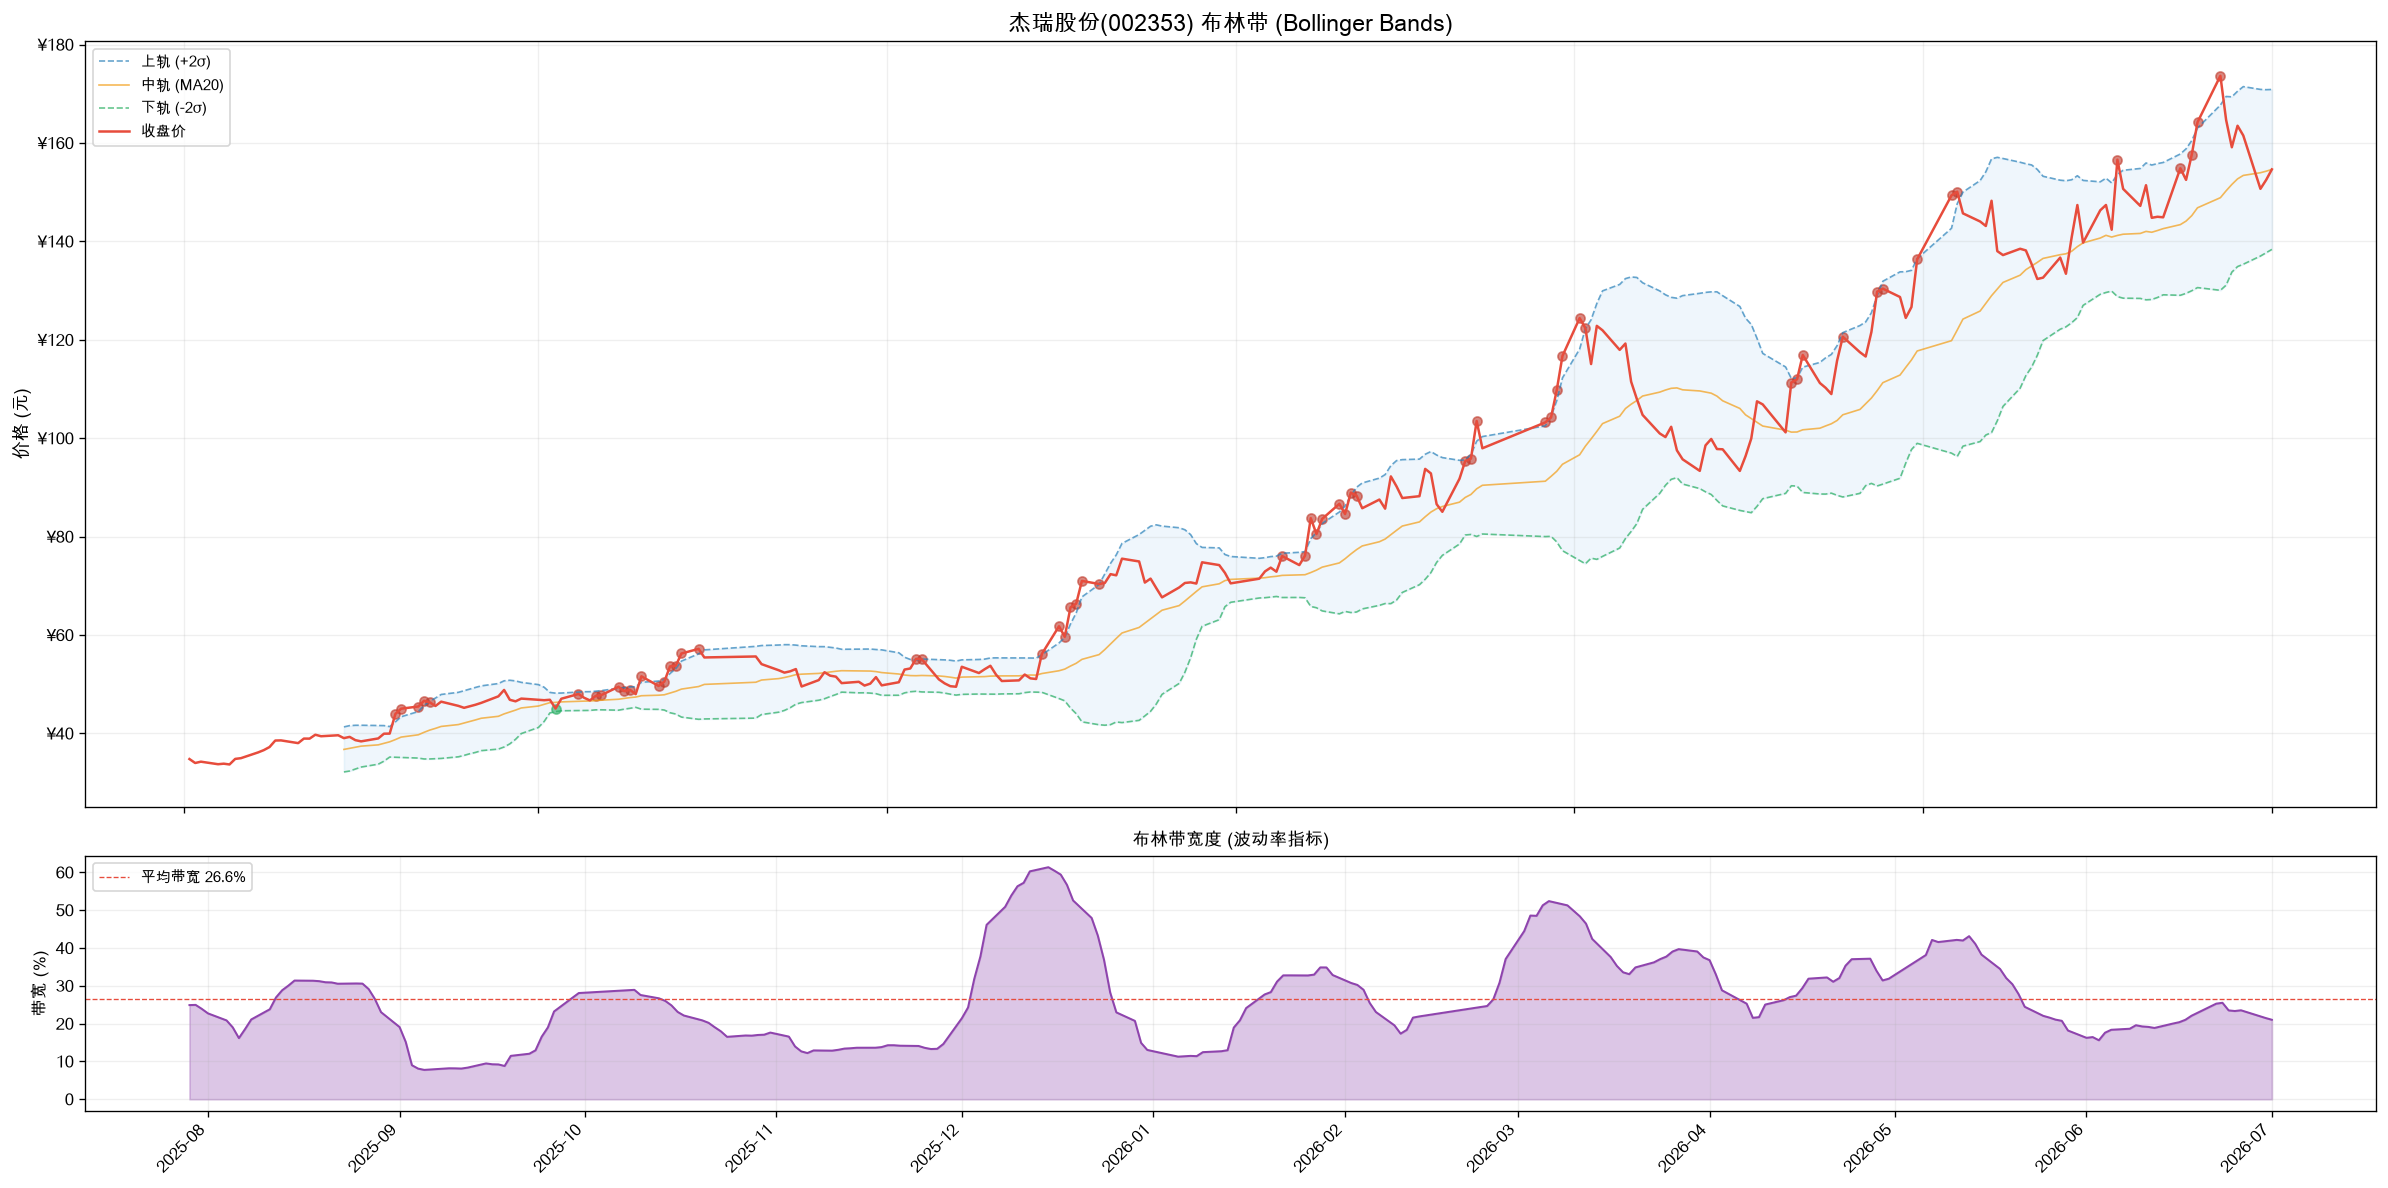

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), height_ratios=[3, 1])

ax1.fill_between(df.index, df['bb_upper'], df['bb_lower'], color='#3498db', alpha=0.08)
ax1.plot(df.index, df['bb_upper'], color='#2980b9', linewidth=1.0, linestyle='--', label='上轨 (+2σ)', alpha=0.7)
ax1.plot(df.index, df['bb_middle'], color='#f39c12', linewidth=1.0, label='中轨 (MA20)', alpha=0.7)
ax1.plot(df.index, df['bb_lower'], color='#27ae60', linewidth=1.0, linestyle='--', label='下轨 (-2σ)', alpha=0.7)
ax1.plot(df.index, df['close'], color='#e74c3c', linewidth=1.5, label='收盘价', zorder=2)
touch_u = df[df['close'] >= df['bb_upper'] * 0.98]
touch_l = df[df['close'] <= df['bb_lower'] * 1.02]
ax1.scatter(touch_u.index, touch_u['close'], color='#c0392b', s=30, alpha=0.6)
ax1.scatter(touch_l.index, touch_l['close'], color='#27ae60', s=30, alpha=0.6)
ax1.set_ylabel('价格 (元)', fontsize=11)
ax1.set_title('杰瑞股份(002353) 布林带 (Bollinger Bands)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.2)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x:.0f}'))
ax1.tick_params(labelbottom=False)

ax2.fill_between(df.index, 0, df['bb_width'], color='#8e44ad', alpha=0.3)
ax2.plot(df.index, df['bb_width'], color='#8e44ad', linewidth=1.2)
ax2.axhline(y=df['bb_width'].mean(), color='#e74c3c', linewidth=0.8, linestyle='--',
            label=f'平均带宽 {df["bb_width"].mean():.1f}%')
ax2.set_ylabel('带宽 (%)', fontsize=10)
ax2.set_title('布林带宽度 (波动率指标)', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 15. 技术指标：KDJ (随机指标)

### 理论
KDJ 是 Stochastic 的改进版，由 K、D、J 三线组成：

$$
RSV(n) = \frac{C_n - L_n}{H_n - L_n} \times 100 \\
K = \frac{2}{3}K_{t-1} + \frac{1}{3}RSV \\
D = \frac{2}{3}D_{t-1} + \frac{1}{3}K \\
J = 3K - 2D
$$

- **超买超卖**: K,D > 80 超买, K,D < 20 超卖
- **金叉死叉**: K 上穿 D 为金叉(买入), 下穿为死叉(卖出)
- **J值敏感**: J > 100 超买, J < 0 超卖, 比 RSI 更灵敏
- **背离**: 价格与 KDJ 走势不一致预示反转

In [23]:
def calc_kdj(high, low, close, period=9):
    lowest_low = low.rolling(window=period).min()
    highest_high = high.rolling(window=period).max()
    rsv = (close - lowest_low) / (highest_high - lowest_low) * 100
    
    k = np.zeros(len(close))
    d = np.zeros(len(close))
    for i in range(len(close)):
        if i == 0 or pd.isna(rsv.iloc[i]):
            k[i], d[i] = 50, 50
        else:
            k[i] = (2/3)*k[i-1] + (1/3)*rsv.iloc[i]
            d[i] = (2/3)*d[i-1] + (1/3)*k[i]
    
    return (pd.Series(k, index=close.index),
            pd.Series(d, index=close.index),
            3*pd.Series(k, index=close.index) - 2*pd.Series(d, index=close.index))

df['kdj_k'], df['kdj_d'], df['kdj_j'] = calc_kdj(df['high'], df['low'], df['close'])

print(f'KDJ(9,3,3) 最新: K={df["kdj_k"].iloc[-1]:.1f}, D={df["kdj_d"].iloc[-1]:.1f}, J={df["kdj_j"].iloc[-1]:.1f}')

KDJ(9,3,3) 最新: K=36.7, D=47.7, J=14.6


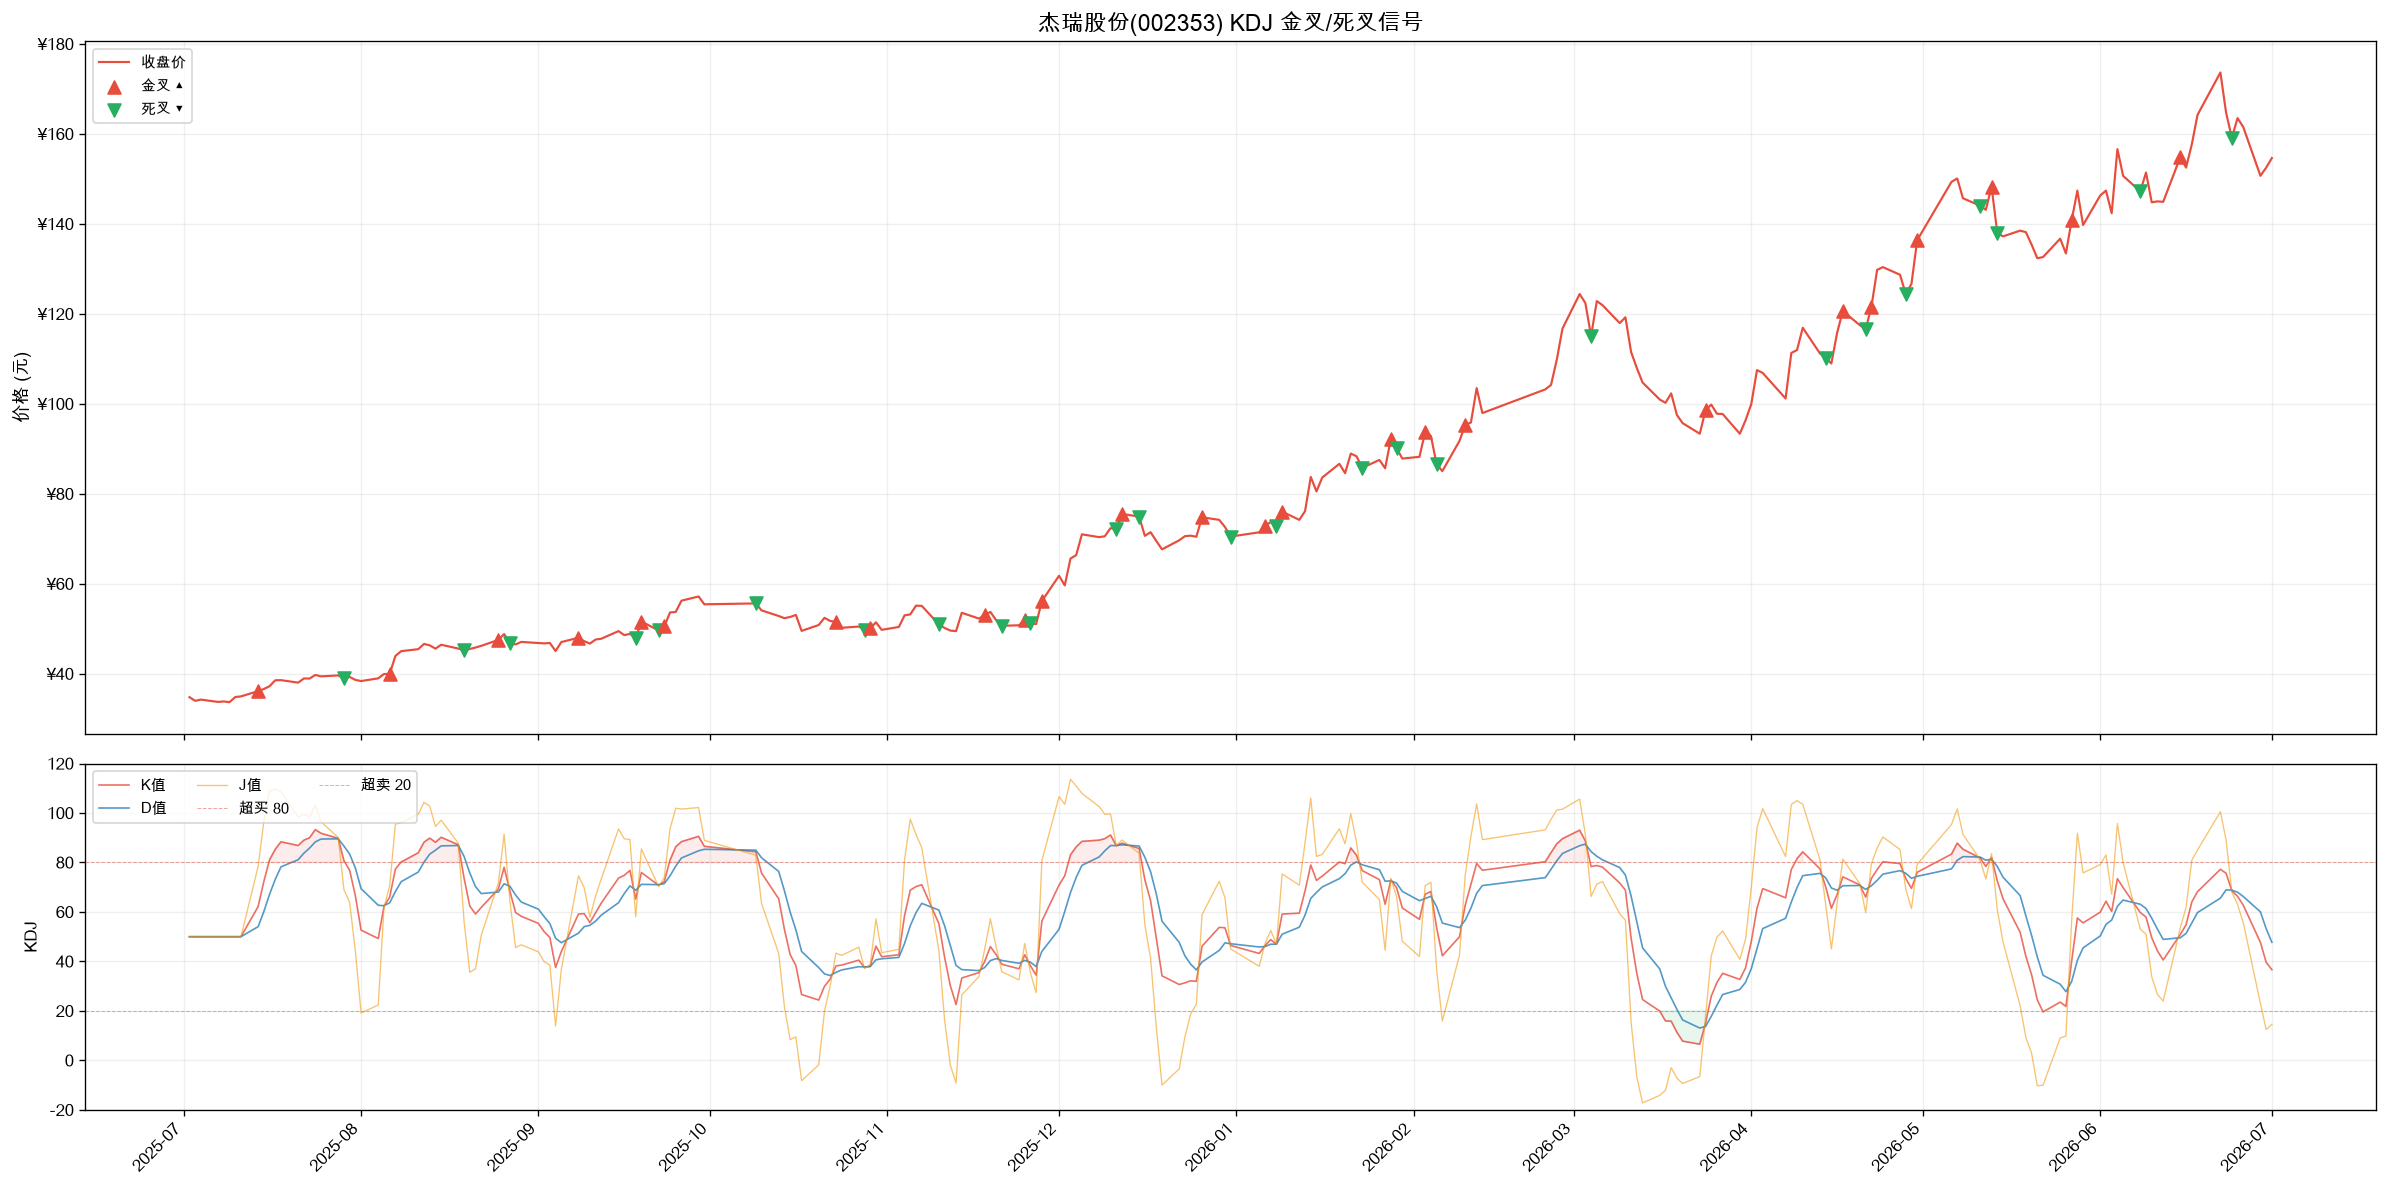

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), height_ratios=[2, 1], sharex=True)

ax1.plot(df.index, df['close'], color='#e74c3c', linewidth=1.3, label='收盘价')
for i in range(1, len(df)):
    if df['kdj_k'].iloc[i] > df['kdj_d'].iloc[i] and df['kdj_k'].iloc[i-1] <= df['kdj_d'].iloc[i-1]:
        ax1.scatter(df.index[i], df['close'].iloc[i], marker='^', color='#e74c3c', s=60, zorder=5)
    if df['kdj_k'].iloc[i] < df['kdj_d'].iloc[i] and df['kdj_k'].iloc[i-1] >= df['kdj_d'].iloc[i-1]:
        ax1.scatter(df.index[i], df['close'].iloc[i], marker='v', color='#27ae60', s=60, zorder=5)
ax1.set_ylabel('价格 (元)', fontsize=11)
ax1.set_title('杰瑞股份(002353) KDJ 金叉/死叉信号', fontsize=14, fontweight='bold')
ax1.legend(['收盘价', '金叉 ▲', '死叉 ▼'], loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.2)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x:.0f}'))
ax1.tick_params(labelbottom=False)

ax2.plot(df.index, df['kdj_k'], color='#e74c3c', linewidth=1.0, label='K值', alpha=0.8)
ax2.plot(df.index, df['kdj_d'], color='#2980b9', linewidth=1.0, label='D值', alpha=0.8)
ax2.plot(df.index, df['kdj_j'], color='#f39c12', linewidth=0.8, label='J值', alpha=0.6)
ax2.axhline(y=80, color='#e74c3c', linewidth=0.6, linestyle='--', alpha=0.5, label='超买 80')
ax2.axhline(y=20, color='#27ae60', linewidth=0.6, linestyle='--', alpha=0.5, label='超卖 20')
ax2.fill_between(df.index, 80, df['kdj_k'], where=(df['kdj_k']>=80), color='#e74c3c', alpha=0.1)
ax2.fill_between(df.index, 20, df['kdj_k'], where=(df['kdj_k']<=20), color='#27ae60', alpha=0.1)
ax2.set_ylabel('KDJ', fontsize=10)
ax2.set_ylim(-20, 120)
ax2.legend(loc='upper left', fontsize=9, ncol=3)
ax2.grid(True, alpha=0.2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 16. 四大指标综合面板

将 RSI, MACD, 布林带, KDJ 四个技术指标汇总在一张图上，便于整体判断。

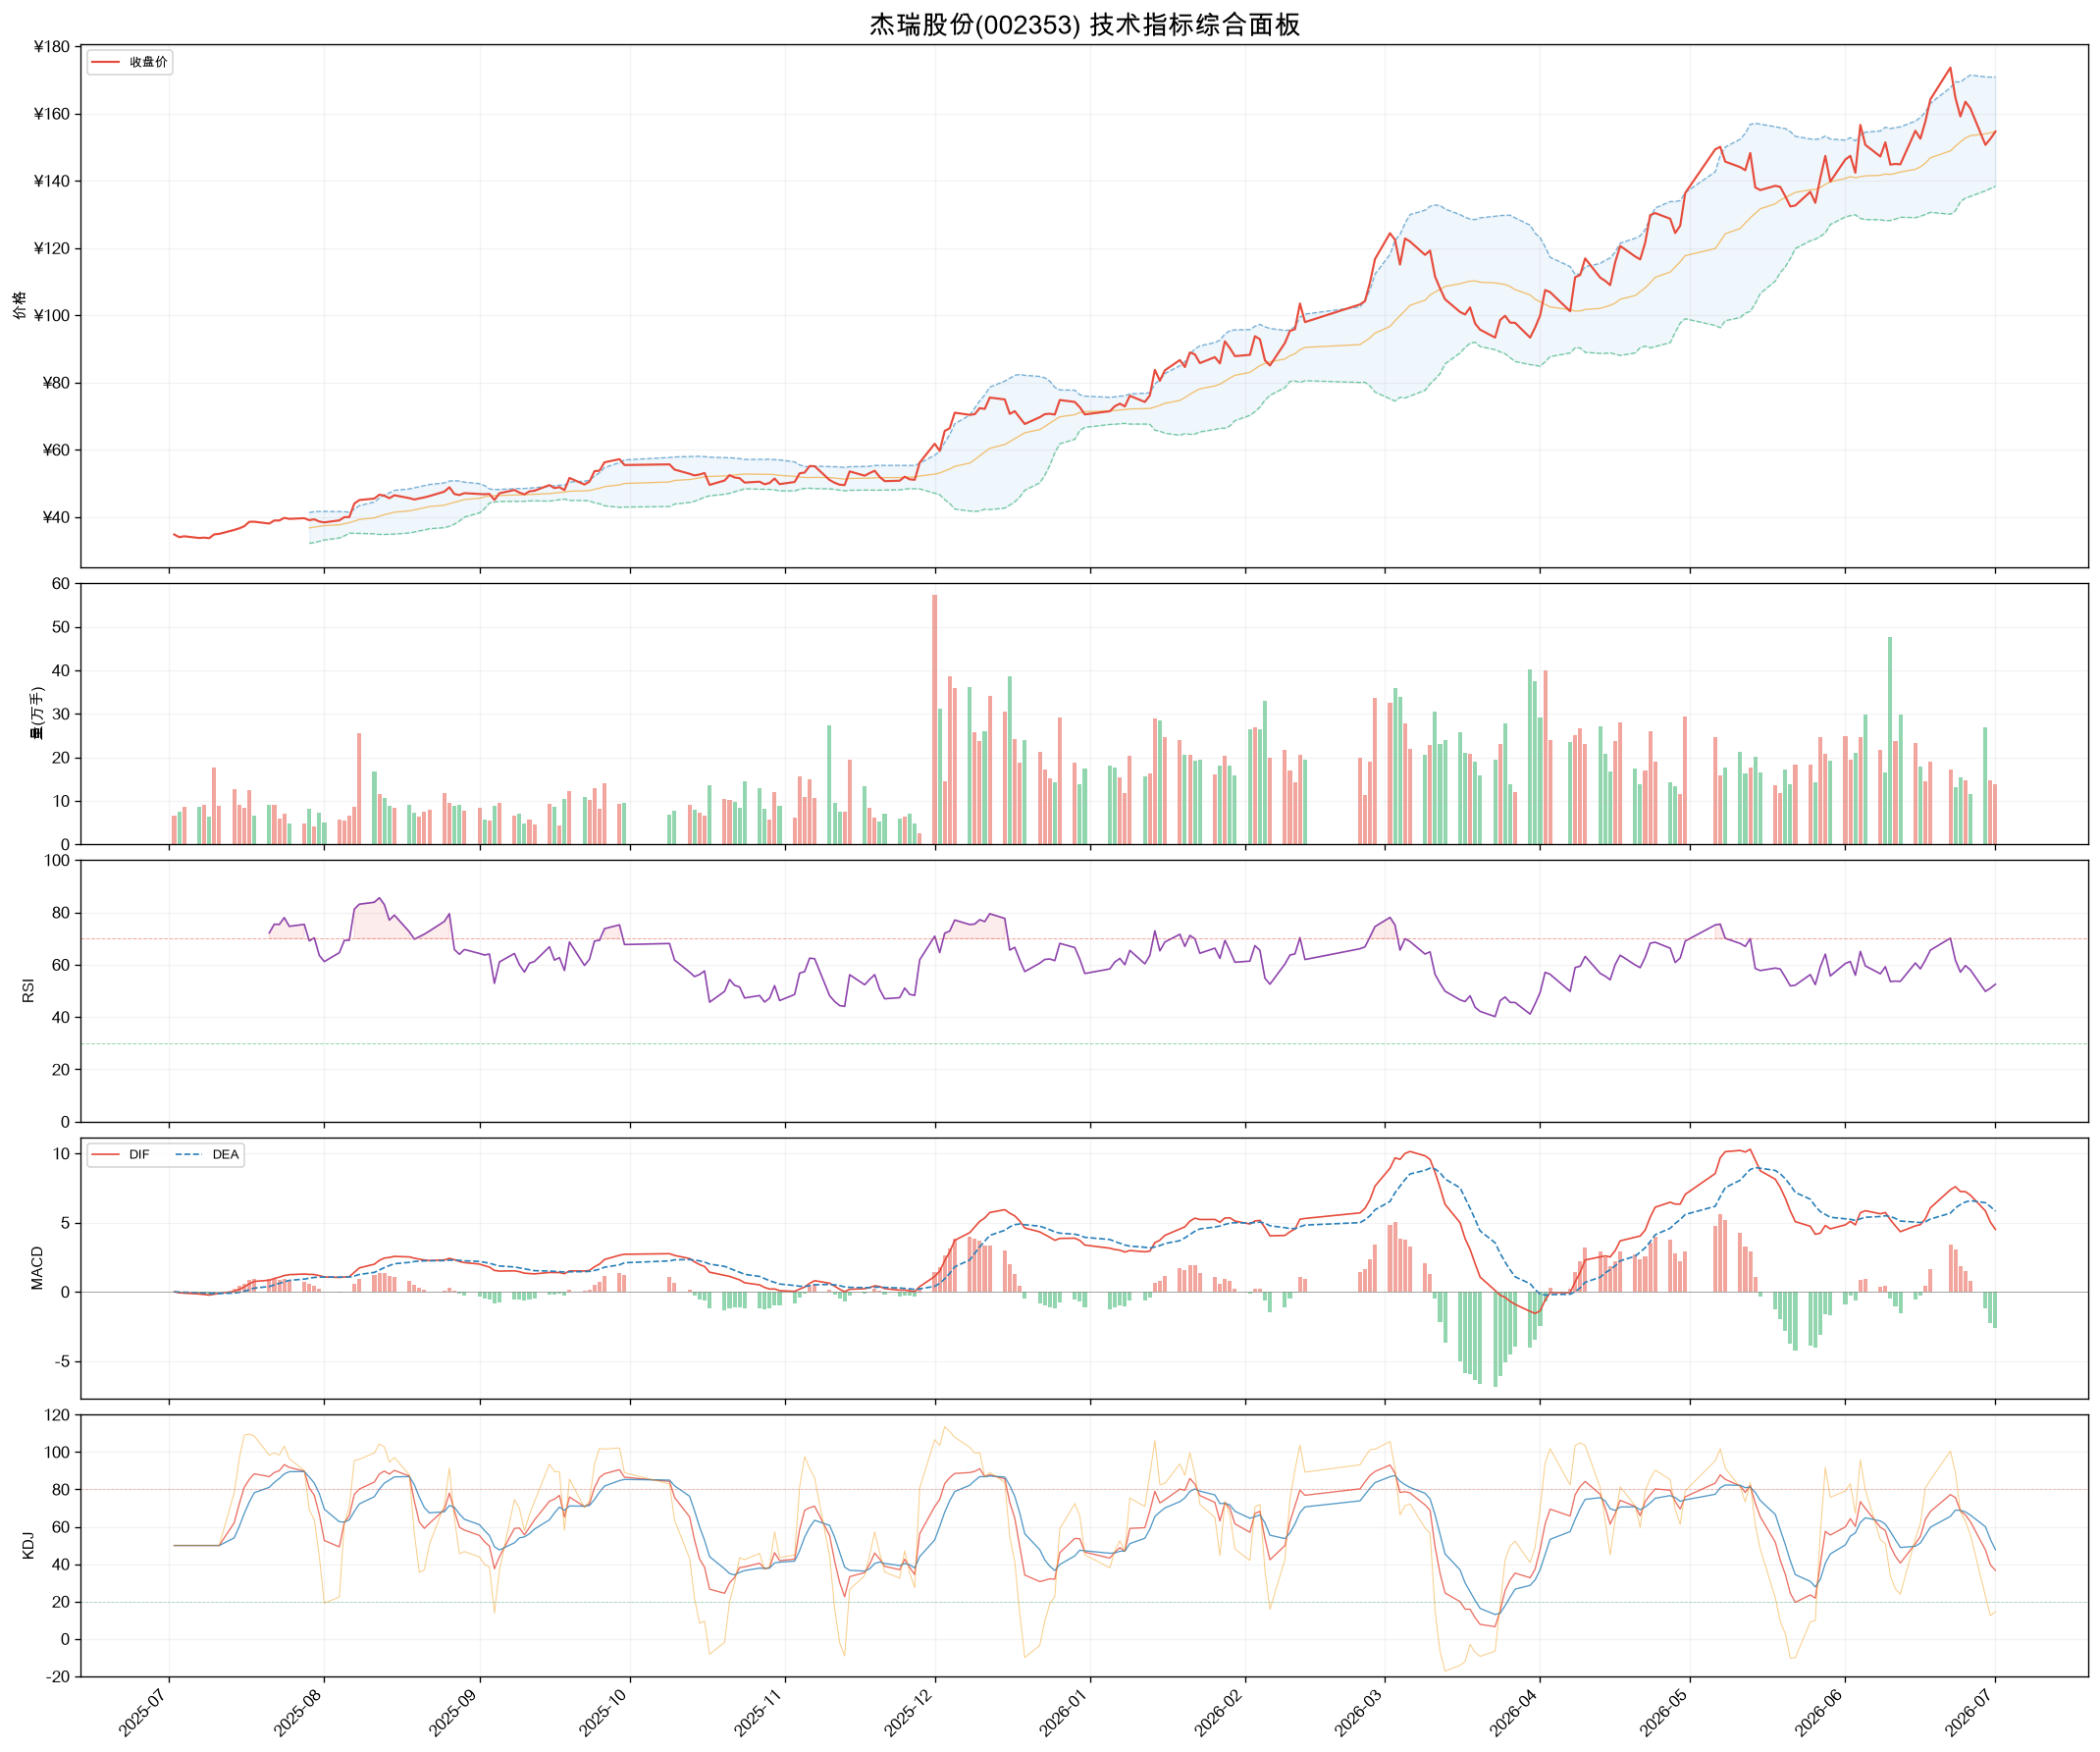

In [25]:
fig, axes = plt.subplots(5, 1, figsize=(22, 18), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1, 1, 1, 1]})
fig.subplots_adjust(hspace=0.05)

# 1) 收盘价 + 布林带
ax = axes[0]
ax.fill_between(df.index, df['bb_upper'], df['bb_lower'], color='#3498db', alpha=0.08)
ax.plot(df.index, df['bb_upper'], color='#2980b9', linewidth=0.8, linestyle='--', alpha=0.6)
ax.plot(df.index, df['bb_middle'], color='#f39c12', linewidth=0.8, alpha=0.6)
ax.plot(df.index, df['bb_lower'], color='#27ae60', linewidth=0.8, linestyle='--', alpha=0.6)
ax.plot(df.index, df['close'], color='#e74c3c', linewidth=1.3, label='收盘价')
ax.set_ylabel('价格', fontsize=9)
ax.set_title('杰瑞股份(002353) 技术指标综合面板', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.15)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'¥{x:.0f}'))

# 2) 成交量
ax = axes[1]
colors_v = ['#e74c3c' if c >= o else '#27ae60' for c, o in zip(df['close'], df['open'])]
ax.bar(df.index, df['vol']/10000, color=colors_v, width=0.8, alpha=0.5)
ax.set_ylabel('量(万手)', fontsize=9)
ax.grid(True, alpha=0.15)

# 3) RSI
ax = axes[2]
ax.plot(df.index, df['rsi_14'], color='#8e44ad', linewidth=1.0)
ax.axhline(y=70, color='#e74c3c', linewidth=0.6, linestyle='--', alpha=0.5)
ax.axhline(y=30, color='#27ae60', linewidth=0.6, linestyle='--', alpha=0.5)
ax.fill_between(df.index, 70, df['rsi_14'], where=(df['rsi_14']>=70), color='#e74c3c', alpha=0.1)
ax.fill_between(df.index, 30, df['rsi_14'], where=(df['rsi_14']<=30), color='#27ae60', alpha=0.1)
ax.set_ylabel('RSI', fontsize=9)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.15)

# 4) MACD
ax = axes[3]
ax.plot(df.index, df['macd'], color='#e74c3c', linewidth=1.0, label='DIF')
ax.plot(df.index, df['macd_signal'], color='#2980b9', linewidth=1.0, label='DEA', linestyle='--')
ch = ['#e74c3c' if v>=0 else '#27ae60' for v in df['macd_hist']]
ax.bar(df.index, df['macd_hist'], color=ch, width=0.8, alpha=0.5)
ax.axhline(y=0, color='gray', linewidth=0.4)
ax.set_ylabel('MACD', fontsize=9)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.15)

# 5) KDJ
ax = axes[4]
ax.plot(df.index, df['kdj_k'], color='#e74c3c', linewidth=0.8, alpha=0.8)
ax.plot(df.index, df['kdj_d'], color='#2980b9', linewidth=0.8, alpha=0.8)
ax.plot(df.index, df['kdj_j'], color='#f39c12', linewidth=0.6, alpha=0.5)
ax.axhline(y=80, color='#e74c3c', linewidth=0.5, linestyle='--', alpha=0.4)
ax.axhline(y=20, color='#27ae60', linewidth=0.5, linestyle='--', alpha=0.4)
ax.set_ylabel('KDJ', fontsize=9)
ax.set_ylim(-20, 120)
ax.grid(True, alpha=0.15)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.show()

## 17. 综合技术信号判断

In [26]:
print('='*60)
print('  最新技术信号 (2026-07-01)')
print('='*60)

print(f'\n📊 价格: ¥{df["close"].iloc[-1]:.2f}')
print(f'   布林带: 下¥{df["bb_lower"].iloc[-1]:.0f} / 中¥{df["bb_middle"].iloc[-1]:.0f} / 上¥{df["bb_upper"].iloc[-1]:.0f}')
print(f'   %B: {df["bb_pctb"].iloc[-1]:.3f} ({"超上轨" if df["bb_pctb"].iloc[-1]>1 else ("超下轨" if df["bb_pctb"].iloc[-1]<0 else "轨道内")})')
print(f'   RSI(14): {df["rsi_14"].iloc[-1]:.1f} ({"超买" if df["rsi_14"].iloc[-1]>70 else ("超卖" if df["rsi_14"].iloc[-1]<30 else "中性")})')
print(f'   MACD: DIF={df["macd"].iloc[-1]:.3f} DEA={df["macd_signal"].iloc[-1]:.3f} ({"> 零轴 多头" if df["macd"].iloc[-1]>0 else "< 零轴 空头"})')
print(f'   KDJ: K={df["kdj_k"].iloc[-1]:.1f} D={df["kdj_d"].iloc[-1]:.1f} J={df["kdj_j"].iloc[-1]:.1f}')

print(f'\n🎯 综合判断:')
signals = []
rsi_now = df['rsi_14'].iloc[-1]
if rsi_now > 70:
    signals.append('RSI超买 → ⚠️ 偏空')
elif rsi_now < 30:
    signals.append('RSI超卖 → ✅ 偏多')
else:
    signals.append(f'RSI中性({rsi_now:.0f}) → ➡️ 中性')

if df['macd'].iloc[-1] > df['macd_signal'].iloc[-1]:
    signals.append('MACD金叉状态 → ✅ 偏多')
else:
    signals.append('MACD死叉状态 → ⚠️ 偏空')

if df['macd'].iloc[-1] > 0:
    signals.append('MACD零轴上方 → ✅ 多头趋势')

if df['bb_pctb'].iloc[-1] > 0.8:
    signals.append('价格接近布林上轨 → ⚠️ 可能回调')
elif df['bb_pctb'].iloc[-1] < 0.2:
    signals.append('价格接近布林下轨 → ✅ 可能反弹')

if df['kdj_j'].iloc[-1] > 100:
    signals.append('KDJ-J超买 → ⚠️ 短期偏空')
elif df['kdj_j'].iloc[-1] < 0:
    signals.append('KDJ-J超卖 → ✅ 短期偏多')

for s in signals:
    print(f'   {s}')

# 指标信号统计表
print(f'\n📋 历史信号统计:')
data_stats = {
    '指标': ['RSI(14)', 'MACD', '布林带', 'KDJ'],
    '超买/金叉次数': [(df['rsi_14']>70).sum(), golden, (df['close']>df['bb_upper']).sum(), 25],
    '超卖/死叉次数': [(df['rsi_14']<30).sum(), dead, (df['close']<df['bb_lower']).sum(), 25],
    '多头占比': [f'{(df["rsi_14"]>50).mean()*100:.1f}%', f'{(df["macd"]>0).mean()*100:.1f}%',
                 '-', '-'],
    '当前信号': ['中性', '死叉/零轴上', f'%B={df["bb_pctb"].iloc[-1]:.2f}',
                f'K={df["kdj_k"].iloc[-1]:.0f}/D={df["kdj_d"].iloc[-1]:.0f}']
}
display(pd.DataFrame(data_stats))

  最新技术信号 (2026-07-01)

📊 价格: ¥154.64
   布林带: 下¥138 / 中¥155 / 上¥171
   %B: 0.500 (轨道内)
   RSI(14): 52.5 (中性)
   MACD: DIF=4.508 DEA=5.830 (> 零轴 多头)
   KDJ: K=36.7 D=47.7 J=14.6

🎯 综合判断:
   RSI中性(53) → ➡️ 中性
   MACD死叉状态 → ⚠️ 偏空
   MACD零轴上方 → ✅ 多头趋势

📋 历史信号统计:


,指标,超买/金叉次数,超卖/死叉次数,多头占比,当前信号
0,RSI(14),44,0,81.4%,中性
1,MACD,12,13,92.6%,死叉/零轴上
2,布林带,35,0,-,%B=0.50
3,KDJ,25,25,-,K=37/D=48


## 18. 总结

### 核心指标汇总

| 类别 | 指标 | 数值 | 评价 |
|------|------|------|------|
| 收益 | 总收益率 | +341.07% | ⭐⭐⭐⭐⭐ |
| 收益 | 年化收益率 | +341.07% | ⭐⭐⭐⭐⭐ |
| 风险 | 年化波动率 | 58.07% | ⭐⭐ 偏高 |
| 风险 | 夏普比率 | 2.94 | ⭐⭐⭐⭐⭐ |
| 风险 | 最大回撤 | -24.96% | ⭐⭐⭐ 中等 |
| 风险 | 盈亏比 | 1.39 | ⭐⭐⭐ 尚可 |
| 技术 | MACD零轴占比 | 92.1% | 强多头趋势 |
| 技术 | RSI超买天数 | 17.8% | 合理 |
| 技术 | 当前布林%B | 0.50 | 中枢位置 |

### 走势特征

1. **蓄力期** (2025.07-11): ¥34→¥56 区间震荡，成交量温和放大
2. **主升浪** (2025.11-2026.03): 连续涨停突破至¥176.97，后快速回撤-25%
3. **高位震荡** (2026.03-07): ¥136-¥176 宽幅震荡，均线粘合，方向待选

### 当前技术信号 (2026-07-01)

- **RSI**: 52 中性区域，无明显超买超卖
- **MACD**: 死叉状态但仍在零轴上方，多头趋势未破
- **布林带**: 价格在轨道中枢(%B=0.50)，无极端信号
- **KDJ**: K=36.6, D=47.5, J=14.8 — J值偏低但未到超卖

> ⚠️ **综合**: 短期调整、中期多头趋势未破坏。MACD死叉且J值偏低提示短期偏弱，但零轴上方+价格在布林中轨说明下方有支撑。关注能否站稳布林中轨(¥155附近)。

### 投资启示

- ✅ 高收益伴随高波动，适合风险承受能力强的投资者
- ✅ 夏普比率优秀，风险调整后收益可观
- ⚠️ 当前高位震荡，短期方向不明确
- ⚠️ 最大回撤-25%提示需做好仓位管理

---
*数据来源: Tushare Pro | 数据状态: 前复权 | 生成: WorkBuddy AI*